# **Milestone 1**

<b>Problem Definition</b>
**The context:** Why is this problem important to solve?<br>
**The objectives:** What is the intended goal?<br>
**The key questions:** What are the key questions that need to be answered?<br>
**The problem formulation:** What is it that we are trying to solve using data science?

## **Data Description:**
The Home Equity dataset (HMEQ) contains baseline and loan performance information for 5,960 recent home equity loans. The target (BAD) is a binary variable that indicates whether an applicant has ultimately defaulted or has been severely delinquent. This adverse outcome occurred in 1,189 cases (20 percent). 12 input variables were registered for each applicant.


* **BAD:** 1 = Client defaulted on loan, 0 = loan repaid

* **LOAN:** Amount of loan approved.

* **MORTDUE:** Amount due on the existing mortgage.

* **VALUE:** Current value of the property. 

* **REASON:** Reason for the loan request. (HomeImp = home improvement, DebtCon= debt consolidation which means taking out a new loan to pay off other liabilities and consumer debts) 

* **JOB:** The type of job that loan applicant has such as manager, self, etc.

* **YOJ:** Years at present job.

* **DEROG:** Number of major derogatory reports (which indicates a serious delinquency or late payments). 

* **DELINQ:** Number of delinquent credit lines (a line of credit becomes delinquent when a borrower does not make the minimum required payments 30 to 60 days past the day on which the payments were due). 

* **CLAGE:** Age of the oldest credit line in months. 

* **NINQ:** Number of recent credit inquiries. 

* **CLNO:** Number of existing credit lines.

* **DEBTINC:** Debt-to-income ratio (all your monthly debt payments divided by your gross monthly income. This number is one way lenders measure your ability to manage the monthly payments to repay the money you plan to borrow.

## <b>Important Notes</b>

- This notebook can be considered a guide to refer to while solving the problem. The evaluation will be as per the Rubric shared for each Milestone. Unlike previous courses, it does not follow the pattern of the graded questions in different sections. This notebook would give you a direction on what steps need to be taken in order to get a viable solution to the problem. Please note that this is just one way of doing this. There can be other 'creative' ways to solve the problem and we urge you to feel free and explore them as an 'optional' exercise. 

- In the notebook, there are markdowns cells called - Observations and Insights. It is a good practice to provide observations and extract insights from the outputs.

- The naming convention for different variables can vary. Please consider the code provided in this notebook as a sample code.

- All the outputs in the notebook are just for reference and can be different if you follow a different approach.

- There are sections called **Think About It** in the notebook that will help you get a better understanding of the reasoning behind a particular technique/step. Interested learners can take alternative approaches if they want to explore different techniques. 

### **Import the necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,precision_score,recall_score,f1_score

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

import scipy.stats as stats

from sklearn.model_selection import GridSearchCV


import warnings
warnings.filterwarnings('ignore')

### **Read the dataset**

In [2]:
hm=pd.read_csv("hmeq.csv")

In [3]:
# Copying data to another variable to avoid any changes to original data
data=hm.copy()

### **Print the first and last 5 rows of the dataset**

In [4]:
# Display first five rows


data.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [5]:
# Display last 5 rows

data.tail()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882
5959,0,89900,48811.0,88934.0,DebtCon,Other,15.0,0.0,0.0,219.601002,0.0,16.0,34.571519


### **Understand the shape of the dataset**

In [6]:
# Check the shape of the data


data.shape

(5960, 13)

**Insights:**
* The data set has **5,960 rows** and **13 columns**.
* There are missing values
* Some rows may be missing many data points

**Generating some Referential Lists for use later in the analysis:**

In [7]:
#Generating a list of all column names
all_cols=data.columns.tolist()

In [8]:
#Generating a list of numerical collumns
num_cols = data.select_dtypes('number').columns.tolist()

In [9]:
#Creating a dictonary of all variable descriptions
variable_descriptions={
    'BAD' : '1 = Client defaulted on loan, 0 = loan repaid',
    'LOAN' : 'Amount of loan approved.',
    'MORTDUE' : 'Amount due on the existing mortgage.',
    'VALUE' : 'Current value of the property.',
    'REASON' : 'Reason for the loan request. (home improvement or debt consolidation)',
    'JOB' : 'The type of job that loan applicant has such as manager, self, etc.',
    'YOJ' : 'Years at present job.',
    'DEROG' : 'Number of major derogatory reports.',
    'DELINQ' : 'Number of delinquent credit lines.',
    'CLAGE' : 'Age of the oldest credit line in months.',
    'NINQ' : 'Number of recent credit inquiries.',
    'CLNO' : 'Number of existing credit lines.',
    'DEBTINC' : 'Debt-to-income ratio.'
}

### **Check the data types of the columns**

In [10]:
# Check info of the data

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


**Insights:**
- `REASON`, and `JOB` are categorical variables.
- `BAD` is of type **int**, but we know from the problem statement, this variable will also be treated as categorical.
- All other collumns are numeric in nature.

### **Check for missing values**

In [11]:
# Analyse missing values - Hint: use isnull() function

data.isnull().sum() 

BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64

In [12]:
# Check the percentage of missing values in the each column.
# Hint: divide the result from the previous code by the number of rows in the dataset


(data.isnull().sum() / data.shape[0])*100


BAD         0.000000
LOAN        0.000000
MORTDUE     8.691275
VALUE       1.879195
REASON      4.228188
JOB         4.681208
YOJ         8.640940
DEROG      11.879195
DELINQ      9.731544
CLAGE       5.167785
NINQ        8.557047
CLNO        3.724832
DEBTINC    21.258389
dtype: float64

In [13]:
#Checking the number of unique values in each collumn
data.nunique()

BAD           2
LOAN        540
MORTDUE    5053
VALUE      5381
REASON        2
JOB           6
YOJ          99
DEROG        11
DELINQ       14
CLAGE      5314
NINQ         16
CLNO         62
DEBTINC    4693
dtype: int64

**Insights**
* `BAD` and `LOAN` have no missing values
* All Other variables have at least 1 missing value
* `DEROG` and `DEBTINC` have a significant number of missing values (over 10% of the entries)

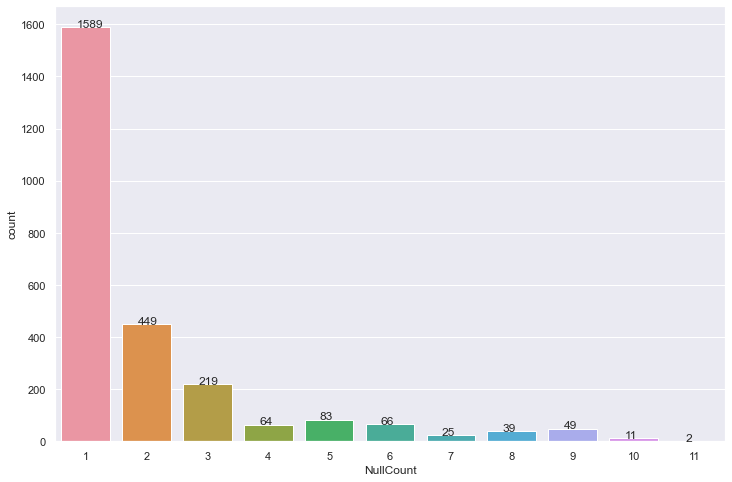

In [14]:
null_counts=pd.DataFrame().assign(NullCount= data.isnull().sum(axis=1))
null_counts=null_counts[null_counts.NullCount!=0]

plt.figure(figsize=(12,8))
ax=sns.countplot(x=null_counts["NullCount"])
for p in ax.patches:
   ax.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))

plt.show()

In [15]:
for i in range(1,12):
    ratio= null_counts['NullCount'].value_counts()[i]/len(data.index)
    print("Percentage of All Rows with", i ,"NaN Values:  ", "%2.2f%%" % (ratio*100), "  (", null_counts['NullCount'].value_counts()[i]," total rows)")

Percentage of All Rows with 1 NaN Values:   26.66%   ( 1589  total rows)
Percentage of All Rows with 2 NaN Values:   7.53%   ( 449  total rows)
Percentage of All Rows with 3 NaN Values:   3.67%   ( 219  total rows)
Percentage of All Rows with 4 NaN Values:   1.07%   ( 64  total rows)
Percentage of All Rows with 5 NaN Values:   1.39%   ( 83  total rows)
Percentage of All Rows with 6 NaN Values:   1.11%   ( 66  total rows)
Percentage of All Rows with 7 NaN Values:   0.42%   ( 25  total rows)
Percentage of All Rows with 8 NaN Values:   0.65%   ( 39  total rows)
Percentage of All Rows with 9 NaN Values:   0.82%   ( 49  total rows)
Percentage of All Rows with 10 NaN Values:   0.18%   ( 11  total rows)
Percentage of All Rows with 11 NaN Values:   0.03%   ( 2  total rows)


**Insights**
* \~26% of the entries have at least one missing value
* 2 of the entries only have data for BAD and LOAN
* Less than 5% of the entries have 5 or more missing values

### **Think about it:**
- We found the total number of missing values and the percentage of missing values, which is better to consider?
    - *Percentage gives a better view of the effect the missing values may have on inferences made about the data*
- What can be the limit for % missing values in a column in order to avoid it and what are the challenges associated with filling them and avoiding them?
    - *Ideally we would like to have no missing data points. Realistically, given the size of the dataset and the variation of the unique values for each of the collumns, in most cases we would like to limit the percentage of missing value to be under 10%*

**We can convert the object type columns to categories**

`converting "objects" to "category" reduces the data space required to store the dataframe`

### **Convert the data types**

In [16]:
cols = data.select_dtypes(['object']).columns.tolist()

#adding target variable to this list as this is an classification problem and the target variable is categorical

cols.append('BAD')

In [17]:
cols

['REASON', 'JOB', 'BAD']

In [18]:
# Changing the data type of object type column to category. hint use astype() function


for i in cols:
    data[i] = data[i].astype('category')

In [19]:
# Checking the info again and the datatype of different variable


data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   BAD      5960 non-null   category
 1   LOAN     5960 non-null   int64   
 2   MORTDUE  5442 non-null   float64 
 3   VALUE    5848 non-null   float64 
 4   REASON   5708 non-null   category
 5   JOB      5681 non-null   category
 6   YOJ      5445 non-null   float64 
 7   DEROG    5252 non-null   float64 
 8   DELINQ   5380 non-null   float64 
 9   CLAGE    5652 non-null   float64 
 10  NINQ     5450 non-null   float64 
 11  CLNO     5738 non-null   float64 
 12  DEBTINC  4693 non-null   float64 
dtypes: category(3), float64(9), int64(1)
memory usage: 483.7 KB


### **Analyze Summary Statistics of the dataset**

In [20]:
# Analyze the summary statistics for numerical variables


data.describe().T

,count,mean,std,min,25%,50%,75%,max
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
MORTDUE,5442.0,73760.817200,44457.609458,2063.000000,46276.000000,65019.000000,91488.000000,399550.000000
VALUE,5848.0,101776.048741,57385.775334,8000.000000,66075.500000,89235.500000,119824.250000,855909.000000
YOJ,5445.0,8.922268,7.573982,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,5252.0,0.254570,0.846047,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,5380.0,0.449442,1.127266,0.000000,0.000000,0.000000,0.000000,15.000000
CLAGE,5652.0,179.766275,85.810092,0.000000,115.116702,173.466667,231.562278,1168.233561
NINQ,5450.0,1.186055,1.728675,0.000000,0.000000,1.000000,2.000000,17.000000
CLNO,5738.0,21.296096,10.138933,0.000000,15.000000,20.000000,26.000000,71.000000
DEBTINC,4693.0,33.779915,8.601746,0.524499,29.140031,34.818262,39.003141,203.312149


**Insights**
* `Derog` and `Delinq` have the least variation in its summary statistics but a high max value which may indicate that likelihood of these occurances is minimal and that the majority of borrows have 0 derogatory reports and delinquent credit lines

In [21]:
# Check summary for categorical data - Hint: inside describe function you can use the argument include=['category']


data.describe(include = ['category']).T

,count,unique,top,freq
BAD,5960,2,0,4771
REASON,5708,2,DebtCon,3928
JOB,5681,6,Other,2388


**Insights**
* The majority of borrowers repaid their loan
* The majority of borrowers did so to consolidate debt
* The majority of borrowers had a job title of "other"

**Let's look at the unique values in all the categorical variables**

In [22]:
# Checking the count of unique values in each categorical column 


cols_cat= data.select_dtypes(['category'])

for i in cols_cat.columns:
    print('Unique values in',i, 'are :')
    print(cols_cat[i].value_counts())
    print('*'*40)

Unique values in BAD are :
0    4771
1    1189
Name: BAD, dtype: int64
****************************************
Unique values in REASON are :
DebtCon    3928
HomeImp    1780
Name: REASON, dtype: int64
****************************************
Unique values in JOB are :
Other      2388
ProfExe    1276
Office      948
Mgr         767
Self        193
Sales       109
Name: JOB, dtype: int64
****************************************


**Insights**
* \~75% of borrowers repaid their loan
* \~65% of borrowers did so to consolidate debt
* \~40% of borrowers had a job type of `Other`
* \~21% of borrowers had a job type of `ProfExe`

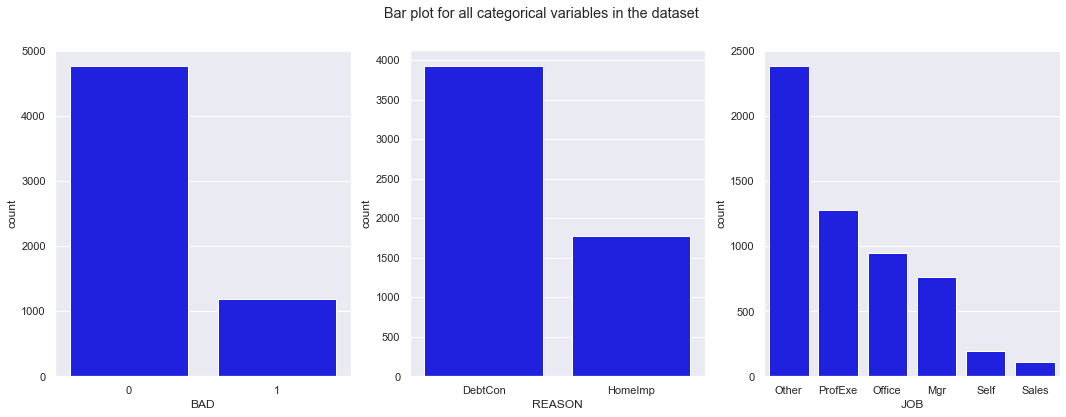

In [23]:
fig, axes = plt.subplots(1, 3, figsize = (18, 6))
  
fig.suptitle('Bar plot for all categorical variables in the dataset')

sns.countplot(ax = axes[0], x = 'BAD', data = data, color = 'blue', 
              order = data['BAD'].value_counts().index);

sns.countplot(ax = axes[1], x = 'REASON', data = data, color = 'blue', 
              order = data['REASON'].value_counts().index);

sns.countplot(ax = axes[2], x = 'JOB', data = data, color = 'blue', 
              order = data['JOB'].value_counts().index);



### **Think about it**
- The results above gave the absolute count of unique values in each categorical column. Are absolute values a good measure? 
- If not, what else can be used? Try implementing that. 

<AxesSubplot:xlabel='REASON', ylabel='BAD'>

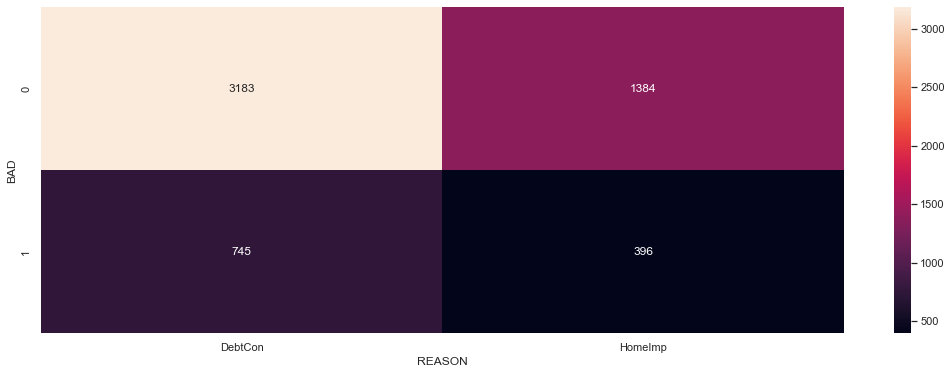

In [24]:
fig = plt.figure(figsize = (18, 6))

sns.heatmap(pd.crosstab(index = data['BAD'], columns = data['REASON']), annot = True, fmt = 'g')


**Insights**
* A greater ratio of borrows that borrowed for home improvement (\~23%) defaulted on their loan than those that consolidated debt (\~19%)

<AxesSubplot:xlabel='JOB', ylabel='BAD'>

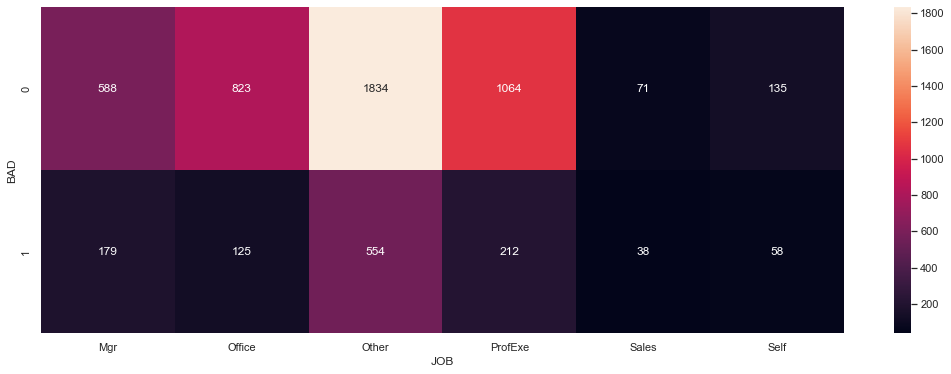

In [25]:
fig = plt.figure(figsize = (18, 6))

sns.heatmap(pd.crosstab(index = data['BAD'], columns = data['JOB']), annot = True, fmt = 'g')


**Insights**
* Borrowers who had job types of `office` and `profexe` had the lowest ratio of defaulting on a loan (*approximately 13% and 17%, respectively*) indicating they are the most likely to repay their loan
* Borrowers who had job types of `sales` and `self` had the highest ratio of defaulting on a loan (*appoximately 35% and 30%, respectively*) indicating they are the most likely to default on their loan
* Both `Mgr` and `other` job types had apprimately 23% of borrowers who defaulted on their loan.

<AxesSubplot:xlabel='JOB', ylabel='REASON'>

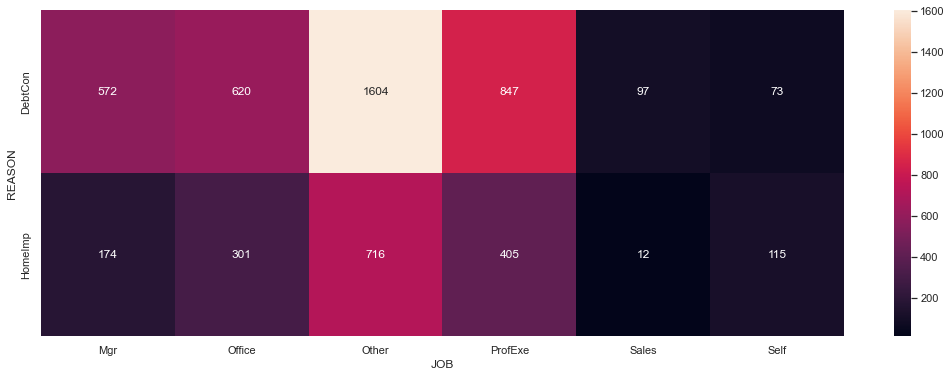

In [26]:
fig = plt.figure(figsize = (18, 6))

sns.heatmap(pd.crosstab(index = data['REASON'], columns = data['JOB']), annot = True, fmt = 'g')


**Insights**
* The job type `Sales` is the least likely to take out a loan for **Home Improvement**, with approximately 11% of Sales types taking a `HomeImp` Loan
* The second least likely job type to take out a loan for **Home Improvement**, is `Sales`, with approximately 23% of Sales types taking a `HomeImp` Loan
* The job type `Self` is the most likely to take out a loan for **Home Improvement**, with approximately 61% of Self types taking a `HomeImp` Loan
* The remaining job types are had approximately 30% of borrowers who took out a loan for **Home Improvement**

## **Exploratory Data Analysis (EDA) and Visualization**

## **Univariate Analysis**

Univariate analysis is used to explore each variable in a data set, separately. It looks at the range of values, as well as the central tendency of the values. It can be done for both numerical and categorical variables

### **1. Univariate Analysis - Numerical Data**
Histograms and box plots help to visualize and describe numerical data. We use box plot and histogram to analyze the numerical columns.

In [27]:
# While doing uni-variate analysis of numerical variables we want to study their central tendency and dispersion.
# Let us write a function that will help us create boxplot and histogram for any input numerical variable.
# This function takes the numerical column as the input and return the boxplots and histograms for the variable.
# Let us see if this help us write faster and cleaner code.
def histogram_boxplot(feature, figsize=(15,10), bins = None):
    """ Boxplot and histogram combined
    feature: 1-d feature array
    figsize: size of fig (default (9,8))
    bins: number of bins (default None / auto)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(nrows = 2, # Number of rows of the subplot grid= 2
                                           sharex = True, # x-axis will be shared among all subplots
                                           gridspec_kw = {"height_ratios": (.25, .75)}, 
                                           figsize = figsize 
                                           ) # creating the 2 subplots
    sns.boxplot(feature, ax=ax_box2, showmeans=True, color='violet') # boxplot will be created and a star will indicate the mean value of the column
    sns.distplot(feature, kde=F, ax=ax_hist2, bins=bins,palette="winter") if bins else sns.distplot(feature, kde=False, ax=ax_hist2) # For histogram
    ax_hist2.axvline(np.mean(feature), color='green', linestyle='--') # Add mean to the histogram
    ax_hist2.axvline(np.median(feature), color='black', linestyle='-') # Add median to the histogram

#### Using the above function, let's first analyze the Histogram and Boxplot for LOAN

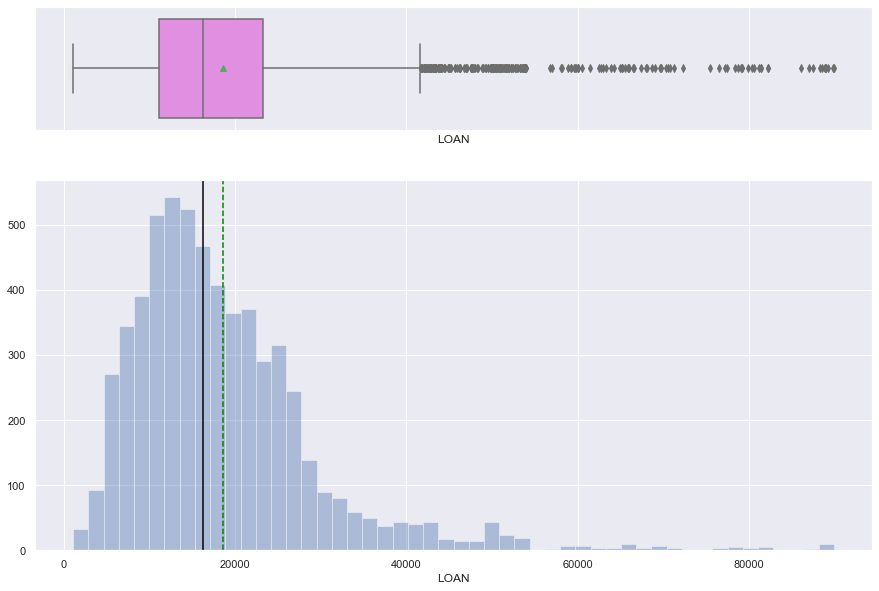

In [28]:
# Build the histogram boxplot for Loan
histogram_boxplot(data['LOAN'])

**Insights**
- The distribution of `Loans` is skewed right with a relatively normal distribution
- There are many outliers, but appear to be evenly spaced and may not need to be treated with 1.5\*IQR

#### **Note:** As done above, analyze Histogram and Boxplot for other variables

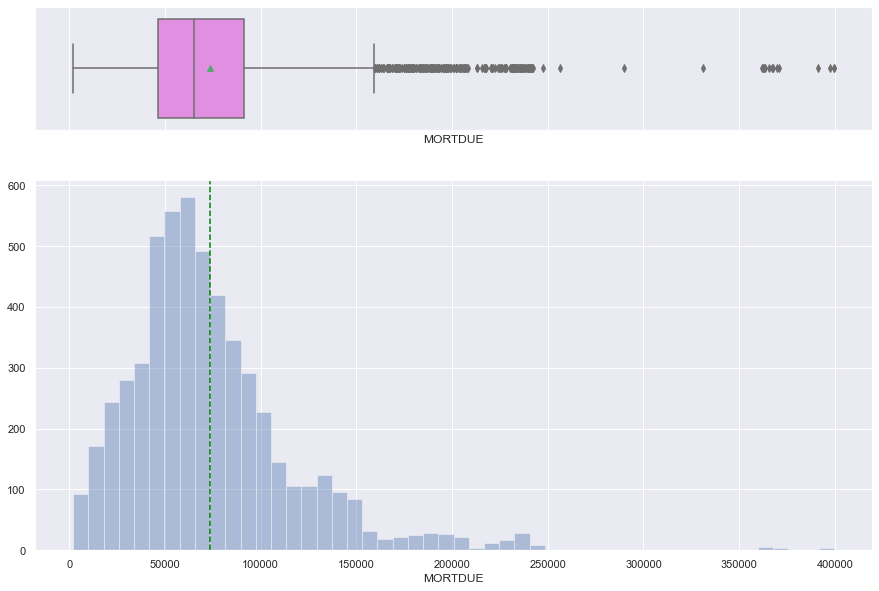

In [29]:
# Build the histogram boxplot for Loan
histogram_boxplot(data['MORTDUE'])

**Insights**
- The distribution of `MORTDUE` is normally distibuted
- There are many outliers in the data with some being significantly greater than the majority, this should be treated by trimming them to 1.5\*IQR

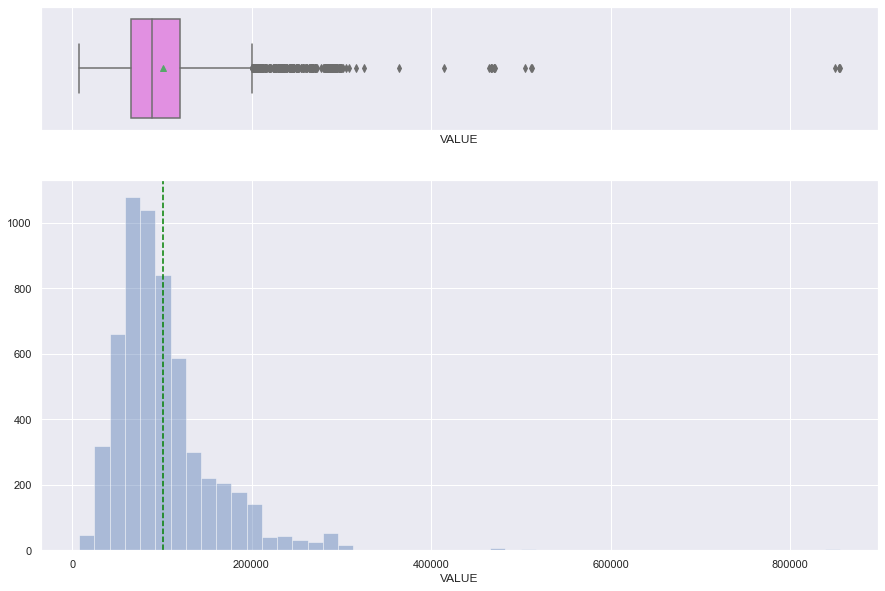

In [30]:
# Build the histogram boxplot for Loan
histogram_boxplot(data['VALUE'])

**Insights**
- The distribution of `VALUE` is normally distibuted
- There are many outliers in the data with some being significantly greater than the majority, this should be treated by trimming them to 1.5\*IQR

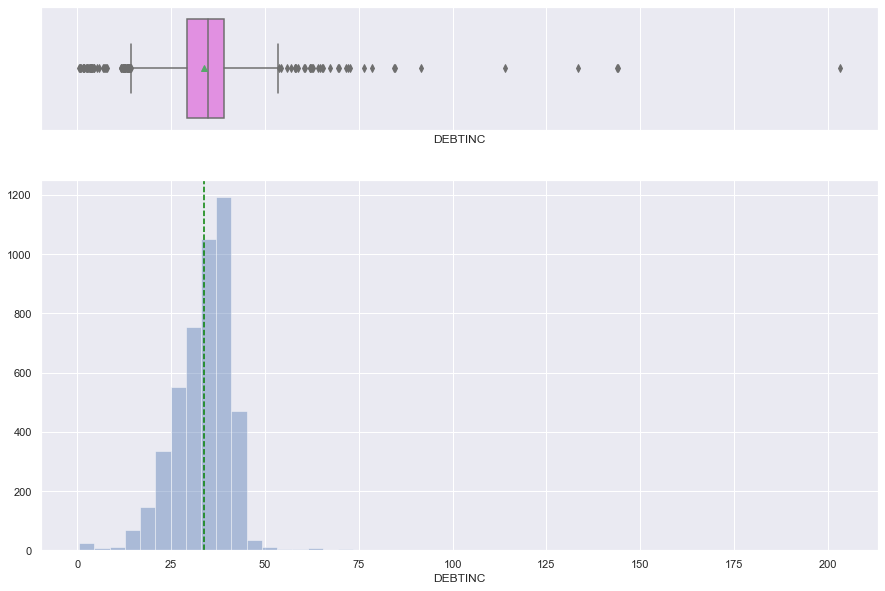

In [31]:
# Build the histogram boxplot for Loan
histogram_boxplot(data['DEBTINC'])

**Insights**
- The distribution of `DEBTINC` is normally distibuted
- There are some outliers in the data with many being significantly greater, or far from the the majority, this should be treated by trimming them to 1.5\*IQR

YOJ :
Years at present job.
Skew : 0.99


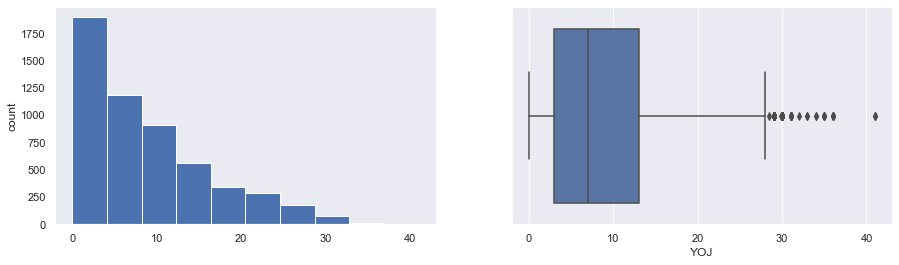

DEROG :
Number of major derogatory reports.
Skew : 5.32


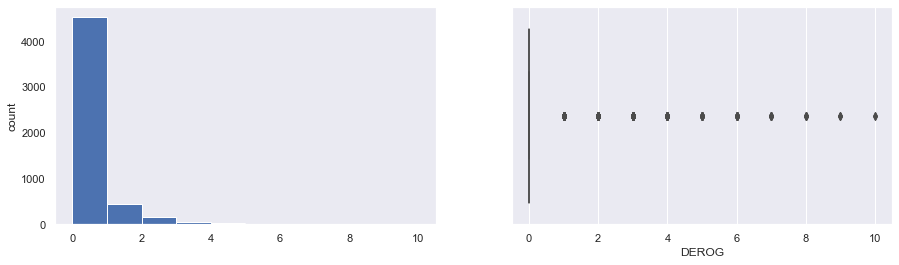

DELINQ :
Number of delinquent credit lines.
Skew : 4.02


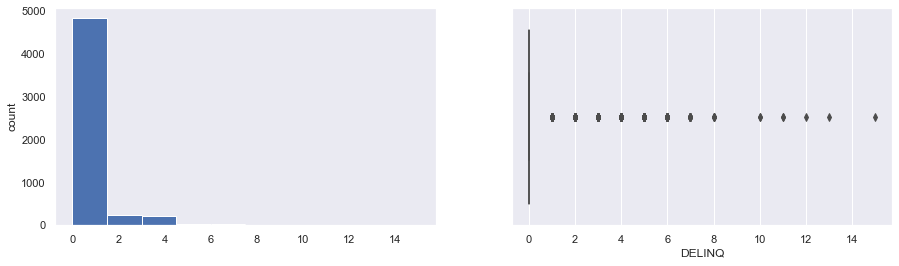

CLAGE :
Age of the oldest credit line in months.
Skew : 1.34


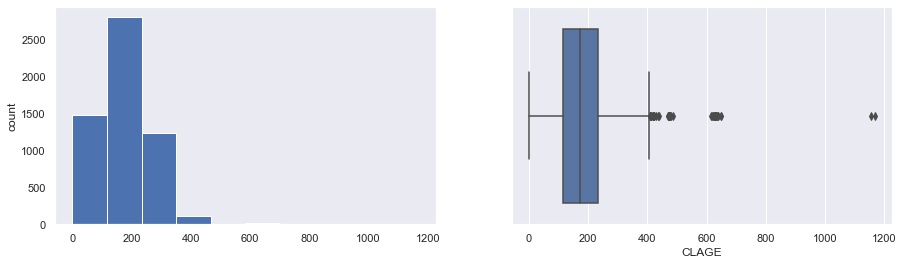

NINQ :
Number of recent credit inquiries.
Skew : 2.62


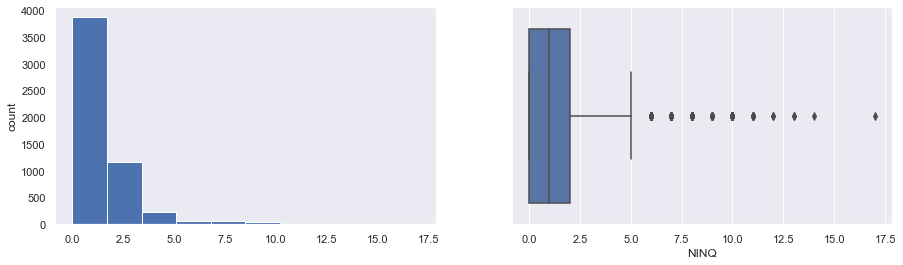

CLNO :
Number of existing credit lines.
Skew : 0.78


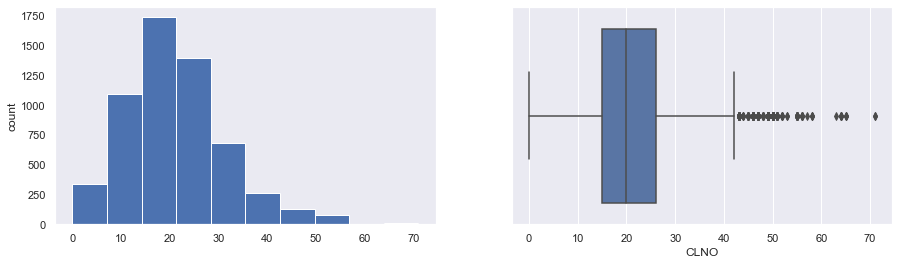

In [32]:
for col in ['YOJ','DEROG','DELINQ','CLAGE','NINQ','CLNO']:
    print(col,":")
    print("\033[92m{}\033[00m".format(variable_descriptions[col]))
    
    print('Skew :',round(data[col].skew(), 2))
    
    plt.figure(figsize = (15, 4))
    
    plt.subplot(1, 2, 1)
    
    data[col].hist(bins = 10, grid = False)
    
    plt.ylabel('count')
    
    plt.subplot(1, 2, 2)
    
    sns.boxplot(x = data[col])
    
    plt.show()


### **2. Univariate Analysis - Categorical Data**

In [33]:
# Function to create barplots that indicate percentage for each category.

def perc_on_bar(plot, feature):
    '''
    plot
    feature: categorical feature
    the function won't work if a column is passed in hue parameter
    '''

    total = len(feature) # length of the column
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total) # percentage of each class of the category
        x = p.get_x() + p.get_width() / 2 - 0.05 # width of the plot
        y = p.get_y() + p.get_height()           # height of the plot
        ax.annotate(percentage, (x, y), size = 12) # annotate the percentage 
        
    plt.show() # show the plot

#### Analyze Barplot for DELINQ

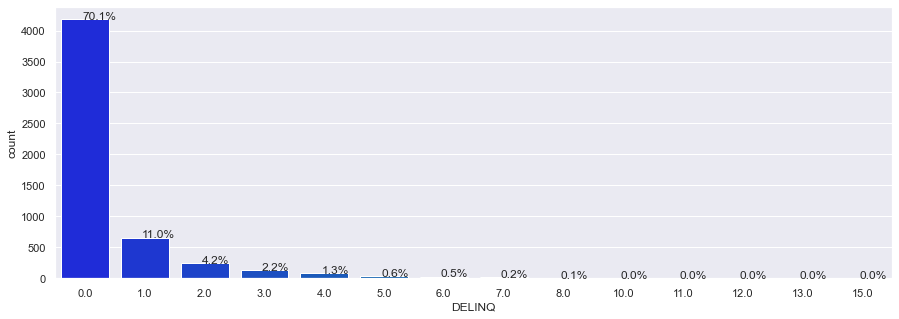

In [34]:
#Build barplot for DELINQ

plt.figure(figsize=(15,5))
ax = sns.countplot(data["DELINQ"],palette='winter')
perc_on_bar(ax,data["DELINQ"])

**Insights**
* Most borrowers did not have delinquent credit lines

## **Bivariate Analysis**

###**Bivariate Analysis: Continuous and Categorical Variables**

#### Analyze BAD vs Loan

<AxesSubplot:xlabel='BAD', ylabel='LOAN'>

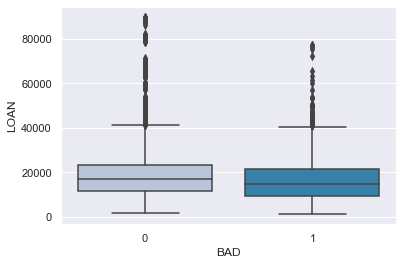

In [35]:
sns.boxplot(data["BAD"],data['LOAN'],palette="PuBu")

**Insights**
* The distribution of repaid loan amount ranges and means are slightly higher than those that defaulted insinuating that larger loans are more likely to be repaid

<AxesSubplot:xlabel='BAD', ylabel='MORTDUE'>

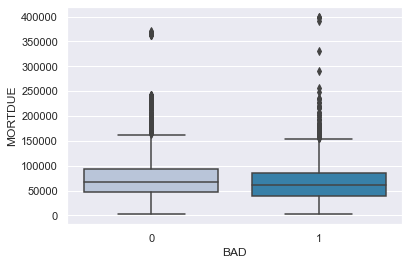

In [36]:
sns.boxplot(data["BAD"],data['MORTDUE'],palette="PuBu")

**Insights**
* The distribution of mortgage ranges and means are slightly lower for those that repaid the loan than those that defaulted.
* Those with mortgages due above 250k were more likely to default

<AxesSubplot:xlabel='BAD', ylabel='VALUE'>

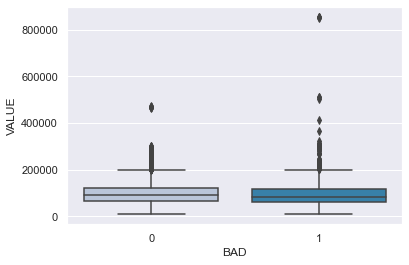

In [37]:
sns.boxplot(data["BAD"],data['VALUE'],palette="PuBu")

<AxesSubplot:xlabel='BAD', ylabel='YOJ'>

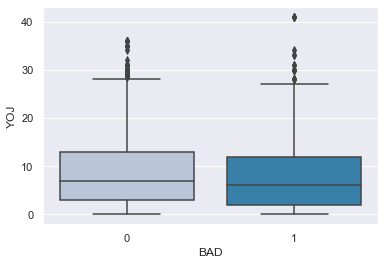

In [38]:
sns.boxplot(data["BAD"],data['YOJ'],palette="PuBu")

<AxesSubplot:xlabel='BAD', ylabel='DEROG'>

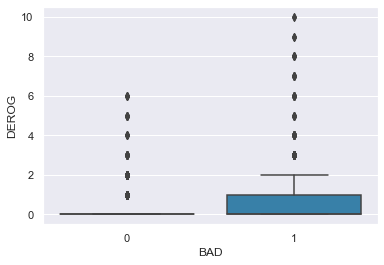

In [39]:
sns.boxplot(data["BAD"],data['DEROG'],palette="PuBu")

<AxesSubplot:xlabel='BAD', ylabel='DELINQ'>

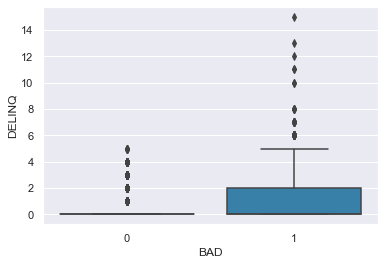

In [40]:
sns.boxplot(data["BAD"],data['DELINQ'],palette="PuBu")

**Insights**
* 6 or more Delinquent Credit lines never repaid their loans

<AxesSubplot:xlabel='BAD', ylabel='CLAGE'>

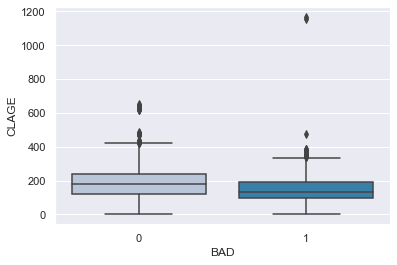

In [41]:
sns.boxplot(data["BAD"],data['CLAGE'],palette="PuBu")

<AxesSubplot:xlabel='BAD', ylabel='NINQ'>

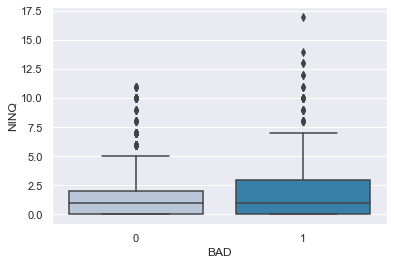

In [42]:
sns.boxplot(data["BAD"],data['NINQ'],palette="PuBu")

<AxesSubplot:xlabel='BAD', ylabel='CLNO'>

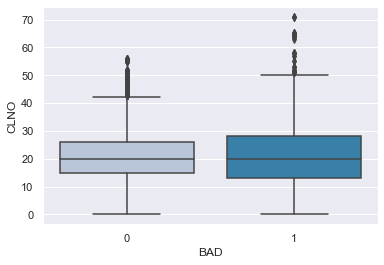

In [43]:
sns.boxplot(data["BAD"],data['CLNO'],palette="PuBu")

<AxesSubplot:xlabel='BAD', ylabel='DEBTINC'>

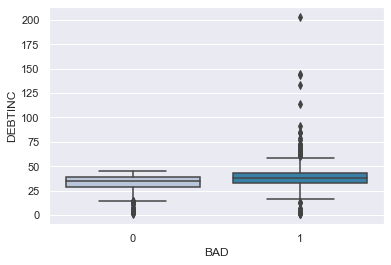

In [44]:
sns.boxplot(data["BAD"],data['DEBTINC'],palette="PuBu")

**Insights**
* Borrowers with a higher depbt to income ratio appear to be more likely to default on their loan

### **Bivariate Analysis: Two Continuous Variables**

<AxesSubplot:xlabel='VALUE', ylabel='MORTDUE'>

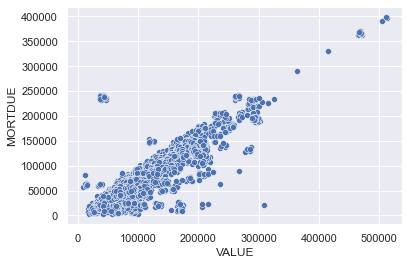

In [45]:
sns.scatterplot(data["VALUE"],data['MORTDUE'],palette="PuBu")

**Insights:**
* There is a strong positive correlation with the value of the property and the amount due on the existing mortgage

<AxesSubplot:xlabel='LOAN', ylabel='VALUE'>

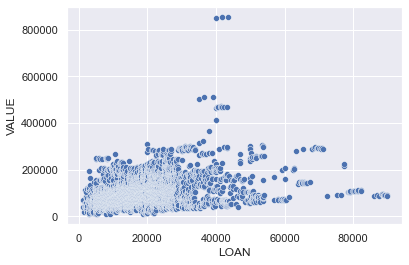

In [46]:
sns.scatterplot(data["LOAN"],data['VALUE'],palette="PuBu")

**Insights**
* There does not appear to be a significant correlation with the loan amount and the value of the property

#### **Note:** As shown above, perform Bivariate Analysis on different pairs of continuous variables

<AxesSubplot:xlabel='CLAGE', ylabel='YOJ'>

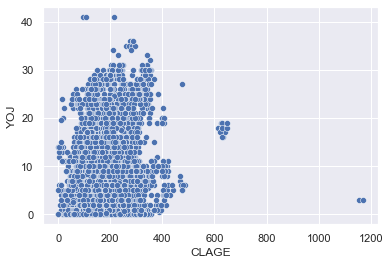

In [47]:
sns.scatterplot(data["CLAGE"],data['YOJ'],palette="PuBu")

<AxesSubplot:xlabel='CLNO', ylabel='CLAGE'>

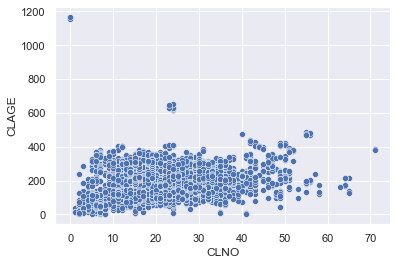

In [48]:
sns.scatterplot(data["CLNO"],data['CLAGE'],palette="PuBu")

### **Bivariate Analysis:  BAD vs Categorical Variables**

**The stacked bar chart (aka stacked bar graph)** extends the standard bar chart from looking at numeric values across one categorical variable to two.

In [49]:
### Function to plot stacked bar charts for categorical columns

def stacked_plot(x):
    sns.set(palette='nipy_spectral')
    tab1 = pd.crosstab(x,data['BAD'],margins=True)
    print(tab1)
    print('-'*120)
    tab = pd.crosstab(x,data['BAD'],normalize='index')
    tab.plot(kind='bar',stacked=True,figsize=(10,5))
    plt.legend(loc='lower left', frameon=False)
    plt.legend(loc="upper left", bbox_to_anchor=(1,1))
    plt.show()

#### Plot stacked bar plot for for LOAN and REASON

BAD         0     1   All
REASON                   
DebtCon  3183   745  3928
HomeImp  1384   396  1780
All      4567  1141  5708
------------------------------------------------------------------------------------------------------------------------


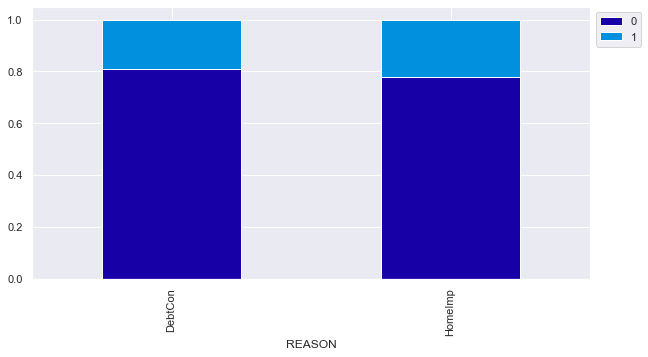

In [50]:
# Plot stacked bar plot for BAD and REASON
stacked_plot(data['REASON'])

**Insights**
* Home improvement loans are more likely to default

BAD         0     1   All
JOB                      
Mgr       588   179   767
Office    823   125   948
Other    1834   554  2388
ProfExe  1064   212  1276
Sales      71    38   109
Self      135    58   193
All      4515  1166  5681
------------------------------------------------------------------------------------------------------------------------


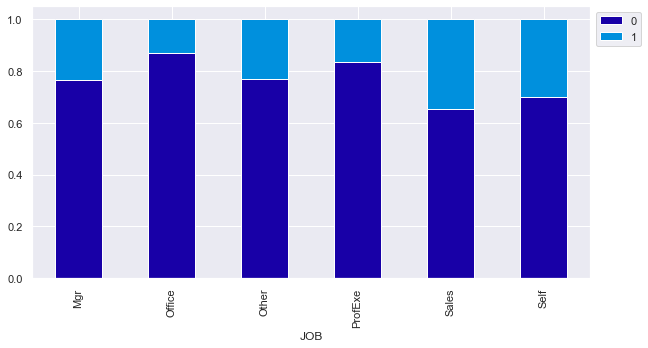

In [51]:
# Plot stacked bar plot for BAD and REASON
stacked_plot(data['JOB'])

#### **Note:** As shown above, perform Bivariate Analysis on different pairs of Categorical vs BAD

**Insights**
* `Sales` and `Self` Are the most likely to default on a loan
* `Office` is the least likely to default on a loan

### **Multivariate Analysis**

#### Analyze Correlation Heatmap for Numerical Variables

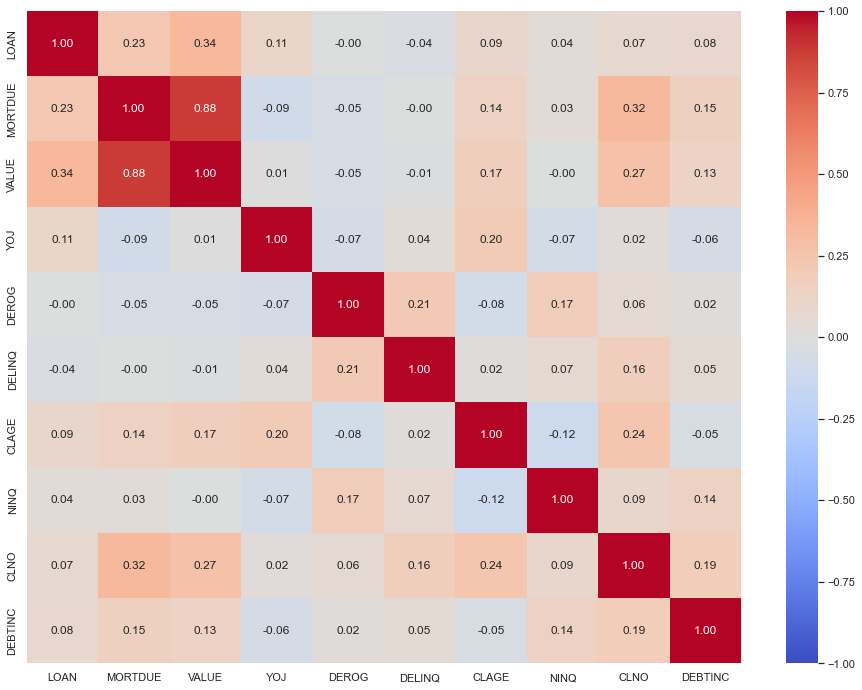

In [52]:
# Separating numerical variables
numerical_col = data.select_dtypes(include=np.number).columns.tolist()

# Build correlation matrix for numerical columns


corr = data[numerical_col].corr()


# plot the heatmap


plt.figure(figsize=(16,12))
sns.heatmap(corr,annot=True,cmap='coolwarm',vmax=1,vmin=-1,
        fmt=".2f",
        xticklabels=corr.columns,
        yticklabels=corr.columns);

**Insights**
- Value and Mortgage due are highly correlated
- Of the remaining variables, the strongest positive correlations are with: 
    - Loan amount with Mortgage Due and Value of Home
    - The amount of existing credit lines and the Mortgage due with Value of home and Credit Age (which is positively correlated with years at job)
    - The number of Derogetory Reports with the number of delinquent credit lines, and the number of recent credit inquiries.
- There is a slight negative correlation with:
    - Years at job with mortgage due and Number of recent credit inquiries
    - Derogatory reports and Credit age
    - Credit age and Debt to income or Number of Credit inquiries
    
- In Summary:
    - Loan amounts are likely to be higher for borrowers with higher home values and/or mortgages, which are highly correlated between the two of them (*i.e. the higher the home value the higher the mortgage*)
    - The longer a borrower has been at their job, the more likely it is that they will have an more credit lines, which in turn may indicate that they have a older credit history and a lower debt to income ratio. They are also more likely to have lower mortgage amounts due, less derogatory reports and less recent credit inquiries.
    - The more Derogatory reports a borrower has, the higher the chance of their having delinquent credit lines and an increased number of credit inquiries.

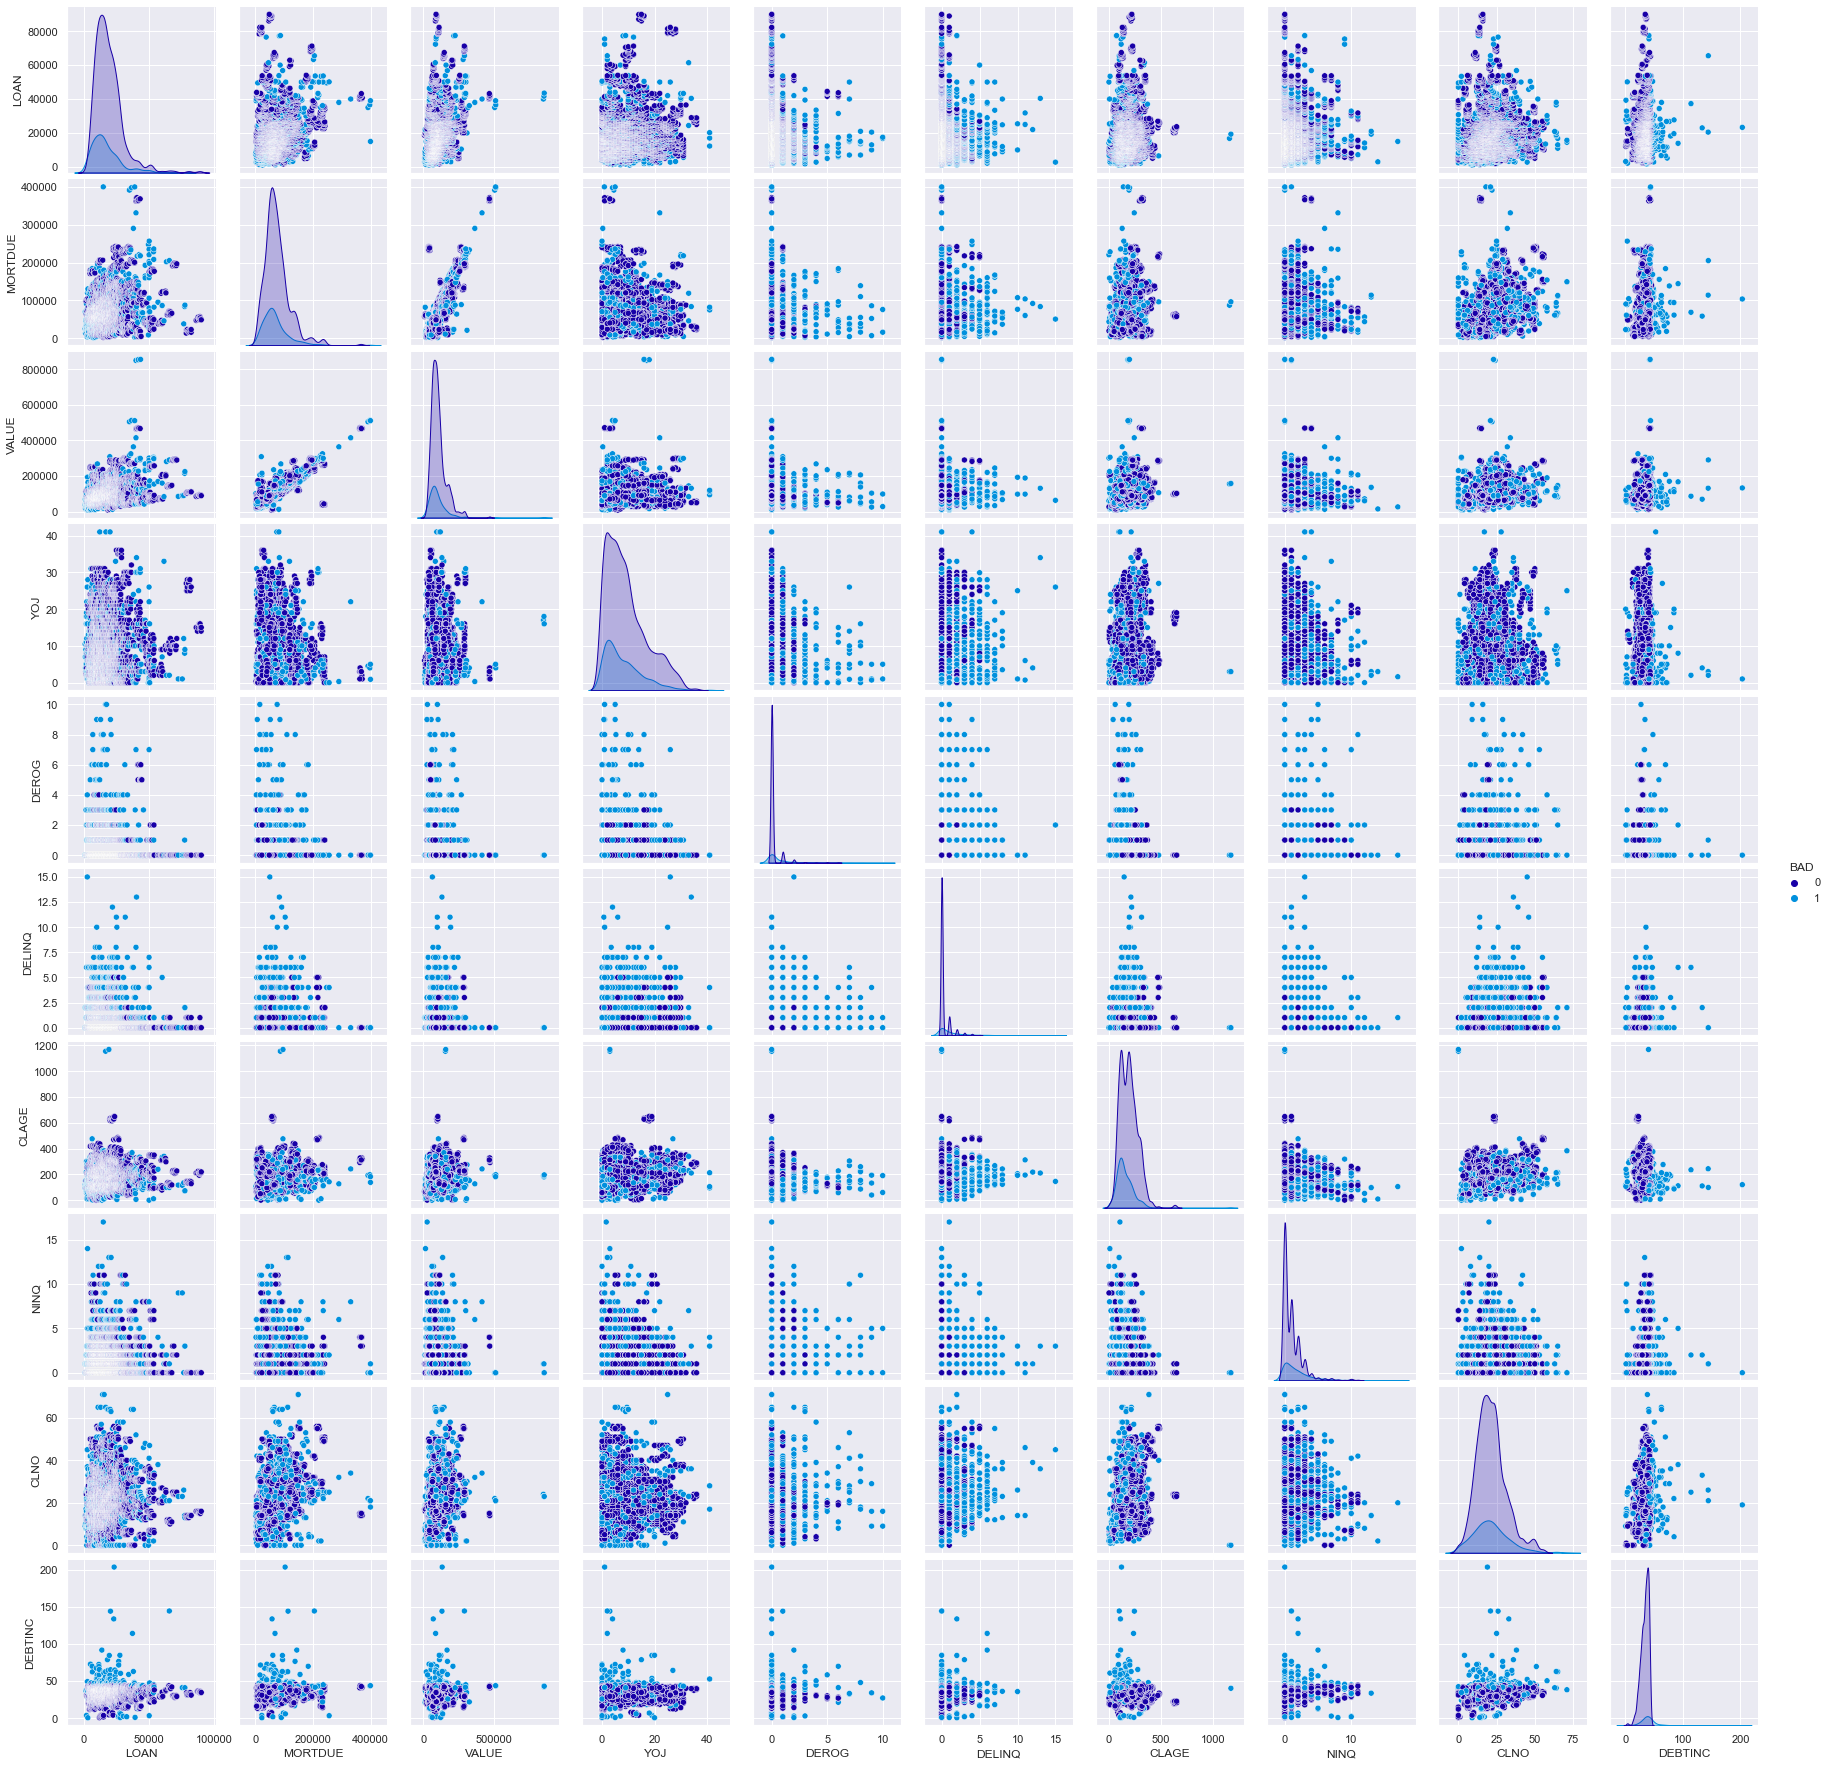

In [53]:
# Build pairplot for the data with hue = 'BAD'

sns.pairplot(data, hue='BAD')

### **Think about it**
- Are there missing values and outliers in the dataset? If yes, how can you treat them? 
- Can you think of different ways in which this can be done and when to treat these outliers or not?
- Can we create new features based on Missing values?

#### Treating Outliers

In [54]:
def treat_outliers(df,col):
    '''
    treats outliers in a varaible
    col: str, name of the numerical varaible
    df: data frame
    col: name of the column
    '''
    
    Q1=np.percentile(df[col], 25) # 25th quantile
    Q3=np.percentile(df[col], 25)  # 75th quantile
    IQR=Q3-Q1   # IQR Range
    Lower_Whisker = Q1-(1.5*IQR)  #define lower whisker
    Upper_Whisker = Q3+(1.5*IQR)  # define upper Whisker
    df[col] = np.clip(df[col], Lower_Whisker, Upper_Whisker) # all the values samller than Lower_Whisker will be assigned value of Lower_whisker 
                                                            # and all the values above upper_whishker will be assigned value of upper_Whisker 
    return df

def treat_outliers_all(df, col_list):
    '''
    treat outlier in all numerical varaibles
    col_list: list of numerical varaibles
    df: data frame
    '''
    for c in col_list:
        df = treat_outliers(df,c)
        
    return df
    

In [55]:
df_raw = data.copy()

numerical_col = df_raw.select_dtypes(include=np.number).columns.tolist()# getting list of numerical columns

df = treat_outliers_all(df_raw,numerical_col)

#### Adding new columns in the dataset for each column which has missing values 

In [56]:
#For each column we create a binary flag for the row, if there is missing value in the row, then 1 else 0. 
def add_binary_flag(df,col):
    '''
    df: It is the dataframe
    col: it is column which has missing values
    It returns a dataframe which has binary falg for missing values in column col
    '''
    new_col = str(col)
    new_col += '_missing_values_flag'
    df[new_col] = df[col].isna()
    return df

In [57]:
# list of columns that has missing values in it
missing_col = [col for col in df.columns if df[col].isnull().any()]

for colmn in missing_col:
    add_binary_flag(df,colmn)
    

#### Filling missing values in numerical columns with median and mode in categorical variables

In [58]:
#  Treat Missing values in numerical columns with median and mode in categorical variables
# Select numeric columns.
num_data = df.select_dtypes('number')

# Select string and object columns.
cat_data = df.select_dtypes('category').columns.tolist()#df.select_dtypes('object')

# Fill numeric columns with median.
# Remove _________ and complete the code
df[num_data.columns] = df[num_data.columns].fillna(df[num_data.columns].median())

# Fill object columns with model.
# Remove _________ and complete the code
for column in cat_data:
    mode = df[column].mode()[0]
    df[column] = df[column].fillna(mode)

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   BAD      5960 non-null   category
 1   LOAN     5960 non-null   int64   
 2   MORTDUE  5442 non-null   float64 
 3   VALUE    5848 non-null   float64 
 4   REASON   5708 non-null   category
 5   JOB      5681 non-null   category
 6   YOJ      5445 non-null   float64 
 7   DEROG    5252 non-null   float64 
 8   DELINQ   5380 non-null   float64 
 9   CLAGE    5652 non-null   float64 
 10  NINQ     5450 non-null   float64 
 11  CLNO     5738 non-null   float64 
 12  DEBTINC  4693 non-null   float64 
dtypes: category(3), float64(9), int64(1)
memory usage: 483.7 KB


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   BAD                          5960 non-null   category
 1   LOAN                         5960 non-null   float64 
 2   MORTDUE                      5960 non-null   float64 
 3   VALUE                        5960 non-null   float64 
 4   REASON                       5960 non-null   category
 5   JOB                          5960 non-null   category
 6   YOJ                          5960 non-null   float64 
 7   DEROG                        5960 non-null   float64 
 8   DELINQ                       5960 non-null   float64 
 9   CLAGE                        5960 non-null   float64 
 10  NINQ                         5960 non-null   float64 
 11  CLNO                         5960 non-null   float64 
 12  DEBTINC                      5960 non-null   float64 
 13  MOR

In [61]:
df.isnull().sum()

BAD                            0
LOAN                           0
MORTDUE                        0
VALUE                          0
REASON                         0
JOB                            0
YOJ                            0
DEROG                          0
DELINQ                         0
CLAGE                          0
NINQ                           0
CLNO                           0
DEBTINC                        0
MORTDUE_missing_values_flag    0
VALUE_missing_values_flag      0
REASON_missing_values_flag     0
JOB_missing_values_flag        0
YOJ_missing_values_flag        0
DEROG_missing_values_flag      0
DELINQ_missing_values_flag     0
CLAGE_missing_values_flag      0
NINQ_missing_values_flag       0
CLNO_missing_values_flag       0
DEBTINC_missing_values_flag    0
dtype: int64

In [62]:
stats.ttest_rel(a=df['DEBTINC_missing_values_flag'], b=df['BAD'])

Ttest_relResult(statistic=2.624719696194697, pvalue=0.008694168386259029)

In [63]:
pd.pivot_table(
    df, 
    values='LOAN', 
    index=['DEBTINC_missing_values_flag'], 
    columns=['BAD'], 
    aggfunc=np.size, 
    fill_value=0
)

BAD,0,1
DEBTINC_missing_values_flag,,
False,4290,403
True,481,786


In [64]:
print("Prabability of Default, given DEBTINC is missing:", 758/(786+481))

Prabability of Default, given DEBTINC is missing: 0.5982636148382005


In [65]:
dfpa=df.copy()

In [66]:
dfpa['dTI>44']= np.where(dfpa["DEBTINC"] > 44 , 'yes', 'no')

dfpa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   BAD                          5960 non-null   category
 1   LOAN                         5960 non-null   float64 
 2   MORTDUE                      5960 non-null   float64 
 3   VALUE                        5960 non-null   float64 
 4   REASON                       5960 non-null   category
 5   JOB                          5960 non-null   category
 6   YOJ                          5960 non-null   float64 
 7   DEROG                        5960 non-null   float64 
 8   DELINQ                       5960 non-null   float64 
 9   CLAGE                        5960 non-null   float64 
 10  NINQ                         5960 non-null   float64 
 11  CLNO                         5960 non-null   float64 
 12  DEBTINC                      5960 non-null   float64 
 13  MOR

In [67]:
pd.pivot_table(
    dfpa, 
    values='LOAN', 
    index=['dTI>44'], 
    columns=['BAD'], 
    aggfunc=np.size, 
    fill_value=0
)

BAD,0,1
dTI>44,,
no,4756,1101
yes,15,88


In [68]:
print("Prabability of Default, given DEBTINC is >44:", 88/(88+15))
print("Prabability of Default, given DEBTINC is <44:", 1101/(4756+1101))

Prabability of Default, given DEBTINC is >44: 0.8543689320388349
Prabability of Default, given DEBTINC is <44: 0.18798019463889362


In [69]:
dfpa['CLA<288']= np.where(dfpa['CLAGE'] < 288 , 'yes', 'no')
dfpa['DTI>1.5']= np.where(dfpa['DELINQ'] > 1.5 , 'yes', 'no')
dfpa['dTIandCA']= np.where((dfpa["DEBTINC"] > 44) & (dfpa['CLAGE']<288), 'yes', 'no')
dfpa['dTIandDCL']= np.where((dfpa["DEBTINC"] > 44) & (dfpa['DELINQ']>1.5), 'yes', 'no')
dfpa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   BAD                          5960 non-null   category
 1   LOAN                         5960 non-null   float64 
 2   MORTDUE                      5960 non-null   float64 
 3   VALUE                        5960 non-null   float64 
 4   REASON                       5960 non-null   category
 5   JOB                          5960 non-null   category
 6   YOJ                          5960 non-null   float64 
 7   DEROG                        5960 non-null   float64 
 8   DELINQ                       5960 non-null   float64 
 9   CLAGE                        5960 non-null   float64 
 10  NINQ                         5960 non-null   float64 
 11  CLNO                         5960 non-null   float64 
 12  DEBTINC                      5960 non-null   float64 
 13  MOR

In [70]:
print(pd.pivot_table(
    dfpa, 
    values='LOAN', 
    index=['dTIandDCL'], 
    columns=['BAD'], 
    aggfunc=np.size, 
    fill_value=0
))

BAD           0     1
dTIandDCL            
no         4771  1170
yes           0    19


In [71]:
print(pd.pivot_table(
    dfpa, 
    values='LOAN', 
    index=['dTIandCA'], 
    columns=['BAD'], 
    aggfunc=np.size, 
    fill_value=0
))

BAD          0     1
dTIandCA            
no        4761  1103
yes         10    86


In [72]:
print(pd.pivot_table(
    dfpa, 
    values='LOAN', 
    index=['DEBTINC_missing_values_flag'], 
    columns=['BAD'], 
    aggfunc=np.size, 
    fill_value=0
))
print("\n -------------- \n")
print(pd.pivot_table(
    dfpa, 
    values='LOAN', 
    index=['dTI>44'], 
    columns=['BAD'], 
    aggfunc=np.size, 
    fill_value=0
))
print("\n -------------- \n")
print(pd.pivot_table(
    dfpa, 
    values='LOAN', 
    index=['CLA<288'], 
    columns=['BAD'], 
    aggfunc=np.size, 
    fill_value=0
))
print("\n -------------- \n")
print(pd.pivot_table(
    dfpa, 
    values='LOAN', 
    index=['DTI>1.5'], 
    columns=['BAD'], 
    aggfunc=np.size, 
    fill_value=0
))
print("\n -------------- \n")
print(pd.pivot_table(
    dfpa, 
    values='LOAN', 
    index=['DEROG_missing_values_flag'], 
    columns=['BAD'], 
    aggfunc=np.size, 
    fill_value=0
))

BAD                             0    1
DEBTINC_missing_values_flag           
False                        4290  403
True                          481  786

 -------------- 

BAD        0     1
dTI>44            
no      4756  1101
yes       15    88

 -------------- 

BAD         0     1
CLA<288            
no        587    66
yes      4184  1123

 -------------- 

BAD         0    1
DTI>1.5           
no       4536  877
yes       235  312

 -------------- 

BAD                           0     1
DEROG_missing_values_flag            
False                      4150  1102
True                        621    87


In [73]:
print("Prabability of Default, given DEBTINC is missing:", 758/(786+481))
print("Prabability of Default, given DEBTINC is >44", 88/(88+15))
print("Prabability of Default, given Credit Age <288:", 1123/(1123+4184))
print("Prabability of Default, given Delinquent CL > 1.5:", 312/(312+235))


Prabability of Default, given DEBTINC is missing: 0.5982636148382005
Prabability of Default, given DEBTINC is >44 0.8543689320388349
Prabability of Default, given Credit Age <288: 0.21160731109854908
Prabability of Default, given Delinquent CL > 1.5: 0.5703839122486288


In [74]:
data.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [75]:
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,...,VALUE_missing_values_flag,REASON_missing_values_flag,JOB_missing_values_flag,YOJ_missing_values_flag,DEROG_missing_values_flag,DELINQ_missing_values_flag,CLAGE_missing_values_flag,NINQ_missing_values_flag,CLNO_missing_values_flag,DEBTINC_missing_values_flag
0,1,11100.0,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,...,False,False,False,False,False,False,False,False,False,True
1,1,11100.0,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,...,False,False,False,False,False,False,False,False,False,True
2,1,11100.0,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,...,False,False,False,False,False,False,False,False,False,True
3,1,11100.0,65019.0,89235.5,DebtCon,Other,7.0,0.0,0.0,173.466667,...,True,True,True,True,True,True,True,True,True,True
4,0,11100.0,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,...,False,False,False,False,False,False,False,False,False,True


## **Proposed approach**
**1. Potential techniques** - What different techniques should be explored?
   - I would explore different treatments of the NULLs than what was done above, such as adding replacing NULLS in the category data with NA

**2. Overall solution design** - What is the potential solution design?
   - In the problem statement, the client expressed a need for interpretability to justify any decision pushback, they will need a graph of key influences given by the random forrest as well as a decision tree
   - The solution will also want to avoid predicting that a borrower will repay the loan but end up defaulting. Meaning we will want to use recall to reduce the rate of false negatives.
   - Steps:
       - Split the data into 20% test and 80% Train due to the difference in the distribution of default and repaid outcomes
       - Implement Logistic Regression, Decision Tree, and Random Forest Models on the data set
       - Tune the models using hyperparameter tuning and grid search
       - Compare the preformance of Logistic Regression, Decision Tree, and Random Forest Models on the data set
       - Choose the best model based on preformance and the client objectives.

**3. Measures of success** - What are the key measures of success?
   - Have at least 85+% accuracy, 70% Recall, and at least 65% precision from the model

# **Milestone 2**

## **Model Building - Approach**
1. Data preparation
2. Partition the data into train and test set
3. Fit on the train data
4. Tune the model and prune the tree, if required
5. Test the model on test set

# Import the Necessary Libraries

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,precision_score,recall_score,f1_score

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

import scipy.stats as stats

from sklearn.model_selection import GridSearchCV


import warnings
warnings.filterwarnings('ignore')

# Loading the Necessary Files

In [77]:
hm=pd.read_csv("hmeq.csv")
# Copying data to another variable to avoid any changes to original data
data=hm.copy()

td=pd.read_csv("treated_data.csv")
# Copying data to another variable to avoid any changes to original data
df=td.copy()

## **Data Preparation**

### **Separating the target variable from other variables**

In [78]:
cols = data.select_dtypes(['object']).columns.tolist()

#adding target variable to this list as this is an classification problem and the target variable is categorical

cols.append('BAD')
cols

['REASON', 'JOB', 'BAD']

In [79]:
# Changing the data type of object type column to category. hint use astype() function

for i in cols:
    data[i] = data[i].astype('category')

In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   BAD      5960 non-null   category
 1   LOAN     5960 non-null   int64   
 2   MORTDUE  5442 non-null   float64 
 3   VALUE    5848 non-null   float64 
 4   REASON   5708 non-null   category
 5   JOB      5681 non-null   category
 6   YOJ      5445 non-null   float64 
 7   DEROG    5252 non-null   float64 
 8   DELINQ   5380 non-null   float64 
 9   CLAGE    5652 non-null   float64 
 10  NINQ     5450 non-null   float64 
 11  CLNO     5738 non-null   float64 
 12  DEBTINC  4693 non-null   float64 
dtypes: category(3), float64(9), int64(1)
memory usage: 483.7 KB


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   5960 non-null   int64  
 1   BAD                          5960 non-null   int64  
 2   LOAN                         5960 non-null   float64
 3   MORTDUE                      5960 non-null   float64
 4   VALUE                        5960 non-null   float64
 5   REASON                       5960 non-null   object 
 6   JOB                          5960 non-null   object 
 7   YOJ                          5960 non-null   float64
 8   DEROG                        5960 non-null   float64
 9   DELINQ                       5960 non-null   float64
 10  CLAGE                        5960 non-null   float64
 11  NINQ                         5960 non-null   float64
 12  CLNO                         5960 non-null   float64
 13  DEBTINC           

In [82]:
del df['Unnamed: 0']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BAD                          5960 non-null   int64  
 1   LOAN                         5960 non-null   float64
 2   MORTDUE                      5960 non-null   float64
 3   VALUE                        5960 non-null   float64
 4   REASON                       5960 non-null   object 
 5   JOB                          5960 non-null   object 
 6   YOJ                          5960 non-null   float64
 7   DEROG                        5960 non-null   float64
 8   DELINQ                       5960 non-null   float64
 9   CLAGE                        5960 non-null   float64
 10  NINQ                         5960 non-null   float64
 11  CLNO                         5960 non-null   float64
 12  DEBTINC                      5960 non-null   float64
 13  MORTDUE_missing_va

In [83]:
df.shape

(5960, 24)

In [84]:
# Drop the dependent variable from the dataframe and create the X(independent variable) matrix
X = df.drop(columns= 'BAD')

# Create dummy variables for the categorical variables - Hint: use the get_dummies() function
X = pd.get_dummies(X, drop_first=True)

# Create y(dependent varibale)


y = df['BAD']

print("X:", X.shape)
print("y:", y.shape)

X: (5960, 27)
y: (5960,)


### **Splitting the data into 70% train and 30% test set**

In [85]:
# Split the data into training and test set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 1)

print("X-Train:", X_train.shape, "\t X-Test:", X_test.shape)
print("y-Train:", y_train.shape, "\t y-Test:", y_test.shape)

X-Train: (4172, 27) 	 X-Test: (1788, 27)
y-Train: (4172,) 	 y-Test: (1788,)


### **Think about it** 
- You can try different splits like 70:30 or 80:20 as per your choice. Does this change in split affect the performance?
- If the data is imbalanced, can you make the split more balanced and if yes, how?

## **Model Evaluation Criterion**

#### After understanding the problem statement, think about which evaluation metrics to consider and why. 

In [86]:
#creating metric function 
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))
    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not Eligible', 'Eligible'], yticklabels=['Not Eligible', 'Eligible'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

### **Build a Logistic Regression Model** 

In [87]:
# Defining the Logistic regression model

lr=LogisticRegression()

# Fitting the model on the training data 


lr.fit(X_train, y_train )


LogisticRegression()

#### Checking the performance on the train dataset

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      3355
           1       0.00      0.00      0.00       817

    accuracy                           0.80      4172
   macro avg       0.40      0.50      0.45      4172
weighted avg       0.65      0.80      0.72      4172



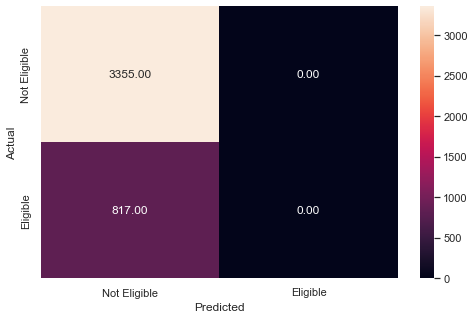

In [88]:
#Predict for train set

train_pred= lr.predict(X_train)

#checking the performance on the train dataset

metrics_score(y_train, train_pred)

#### Checking the performance on the test dataset

              precision    recall  f1-score   support

           0       0.79      1.00      0.88      1416
           1       0.00      0.00      0.00       372

    accuracy                           0.79      1788
   macro avg       0.40      0.50      0.44      1788
weighted avg       0.63      0.79      0.70      1788



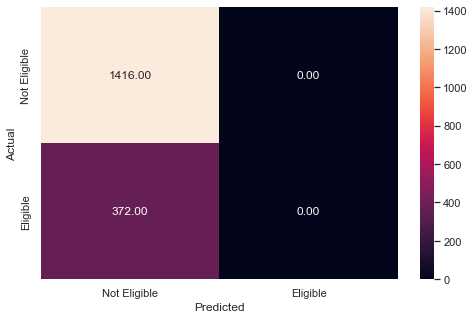

In [89]:
#Predict for test set


test_pred= lr.predict(X_test)

#checking the performance on the test dataset


metrics_score(y_test, test_pred)

**Observations:**
- Recall for 0 is 1.0
- There are exactly 0 data points for any prediction of an applicant being eligable/repaying the loan, indicating this model would reject every loan application

#### Let's check the coefficients, and check which variables are important and how they affect the process of loan approval

Feature: 0, Score:-0.00002
Feature: 1, Score:-0.00000
Feature: 2, Score:0.00000
Feature: 3, Score:-0.00022
Feature: 4, Score:0.00007
Feature: 5, Score:0.00010
Feature: 6, Score:-0.00580
Feature: 7, Score:0.00008
Feature: 10, Score:-0.00017
Feature: 11, Score:-0.00003
Feature: 12, Score:-0.00000
Feature: 13, Score:0.00001
Feature: 14, Score:-0.00000
Feature: 15, Score:-0.00001
Feature: 16, Score:-0.00001
Feature: 17, Score:-0.00001
Feature: 20, Score:-0.00001
Feature: 21, Score:-0.00000
Feature: 22, Score:-0.00001
Feature: 23, Score:-0.00000
Feature: 24, Score:0.00006
Feature: 25, Score:-0.00001
Feature: 26, Score:-0.00001
Feature: 27, Score:-0.00001
Feature: 30, Score:-0.00001
Feature: 31, Score:0.00000
Feature: 32, Score:0.00000


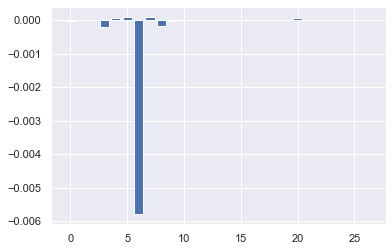

In [90]:
# Printing the coefficients of logistic regression


importance = lr.coef_[0]

for i,j in enumerate(importance):
    print('Feature: %o, Score:%.5f'% (i,j))
plt.bar([X for X in range(len(importance))], importance)
plt.show()

In [91]:
print(importance[7])

7.671794842563671e-05


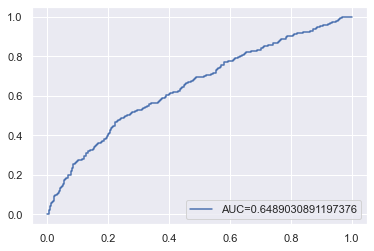

In [92]:
#define metrics
y_prob=lr.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_prob)
auc = metrics.roc_auc_score(y_test, y_prob)

#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.legend(loc=4)
plt.show()

**Insights**
- An AUC of 0.64 indicates the model is doing slightly better than just guesing the outcome
- Overall the Logistical regression model is not giving good results, paticularily the recall of the test set.
- The Logistic Regression model is also not interpretable, while it does state the distribution of impartances we do not have a way to interpret which ones they are.

### **Think about it:**
- The above Logistic regression model was build on the threshold of 0.5, can we use different threshold?
    - Yes you can test with different threshholds
- How to get an optimal threshold and which curve will help you achieve?
    - Implement a comparison logic that keep iterating through different threashhold until you acheive optimal results
- How does, accuracy, precision and recall change on the threshold?
    - The accuracy, precision and recall should improve with the threshold
    
*I am not going to pursue tuning the Logistic Regression Model as it's lack of interpretability will not satisfy the needs of the client and would rather focus on the comparison of Decision Tree vs. Ranodm Forest.*

### **Build a Decision Tree Model**

### **Think about it:**
- In Logistic regression we treated the outliers and built the model, should we do the same for tree based models or not? If not, why? 
    - I would say that we should use the same data structure for testing each of the models, if we include outliers in one we should re-test by including them all.
    - If i had more time i would actually like to know the difference in the results of different treatment methods. Personally, i would have had a much different approach in treating the Null values and more selective in the treatment of outliers.

#### Data Preparation for the tree based model

In [93]:
#For each column we create a binary flag for the row, if there is missing value in the row, then 1 else 0. 
def add_binary_flag(df,col):
    '''
    df: It is the dataframe
    col: it is column which has missing values
    It returns a dataframe which has binary falg for missing values in column col
    '''
    new_col = str(col)
    new_col += '_missing_values_flag'
    df[new_col] = df[col].isna()
    return df

In [94]:
# This is already accomplished in df

# Add binary flags
# List of columns that has missing values in it
missing_col = [col for col in data.columns if data[col].isnull().any()]

for colmn in missing_col:
    add_binary_flag(data,colmn)


In [95]:

#  Treat Missing values in numerical columns with median and mode in categorical variables
# Select numeric columns.
num_data = data.select_dtypes('number')

# Select string and object columns.
cat_data = data.select_dtypes('category').columns.tolist()#df.select_dtypes('object')

# Fill numeric columns with median.

data[num_data.columns] = num_data.fillna(data[num_data.columns].median())

# Fill object columns with model.

for column in cat_data:
    mode = data[column].mode()[0]
    data[column] = data[column].fillna(mode)


In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   BAD                          5960 non-null   category
 1   LOAN                         5960 non-null   int64   
 2   MORTDUE                      5960 non-null   float64 
 3   VALUE                        5960 non-null   float64 
 4   REASON                       5960 non-null   category
 5   JOB                          5960 non-null   category
 6   YOJ                          5960 non-null   float64 
 7   DEROG                        5960 non-null   float64 
 8   DELINQ                       5960 non-null   float64 
 9   CLAGE                        5960 non-null   float64 
 10  NINQ                         5960 non-null   float64 
 11  CLNO                         5960 non-null   float64 
 12  DEBTINC                      5960 non-null   float64 
 13  MOR

#### Separating the target variable y and independent variable x

In [97]:
# Drop dependent variable from dataframe and create the X(independent variable) matrix


X = data.drop(columns = 'BAD')

# Create dummy variables for the categorical variables - Hint: use the get_dummies() function

X = pd.get_dummies(X, drop_first = True)

# Create y(dependent varibale)


y = data['BAD']

#### Split the data

In [98]:
# Split the data into training and test set


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 1)

In [99]:
print("Shape of the training set: ", X_train.shape)   

print("Shape of the test set: ", X_test.shape)

print("Percentage of classes in the training set:")

print(y_train.value_counts(normalize = True))

print("Percentage of classes in the test set:")

print(y_test.value_counts(normalize = True))

Shape of the training set:  (4768, 27)
Shape of the test set:  (1192, 27)
Percentage of classes in the training set:
0    0.802643
1    0.197357
Name: BAD, dtype: float64
Percentage of classes in the test set:
0    0.791946
1    0.208054
Name: BAD, dtype: float64


In [100]:
#Defining Decision tree model with class weights class_weight={0: 0.2, 1: 0.8}

d_tree = DecisionTreeClassifier(class_weight = {0: 0.2, 1: 0.8}, random_state = 1)
DecisionTreeClassifier()

DecisionTreeClassifier()

In [101]:
#fitting Decision tree model

d_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.2, 1: 0.8}, random_state=1)

#### Checking the performance on the train dataset

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3827
           1       1.00      1.00      1.00       941

    accuracy                           1.00      4768
   macro avg       1.00      1.00      1.00      4768
weighted avg       1.00      1.00      1.00      4768



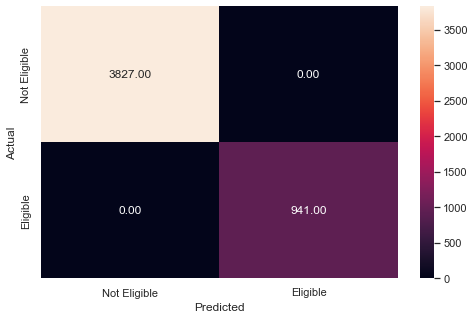

In [102]:
# Checking performance on the training data


y_pred_train1 = d_tree.predict(X_train)

metrics_score(y_train, y_pred_train1)

#### Checking the performance on the test dataset

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       944
           1       0.71      0.63      0.67       248

    accuracy                           0.87      1192
   macro avg       0.81      0.78      0.79      1192
weighted avg       0.86      0.87      0.87      1192



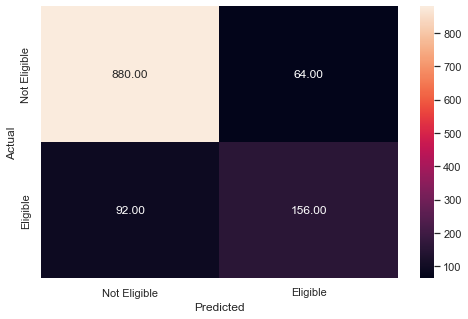

In [103]:
# Checking performance on the testing data


y_pred_test1 = d_tree.predict(X_test)

metrics_score(y_test, y_pred_test1)

**Insights**
- The recall score is not good and the un-tuned decision tree is favoring precision. A tuned model may produce results more appropriate for our objective.

### **Think about it:**
- Can we improve this model? 
    - Tuning
- How to get optimal parameters in order to get the best possible results?
    - Use grid search to figure it out for us

### **Decision Tree - Hyperparameter Tuning**

* Hyperparameter tuning is tricky in the sense that **there is no direct way to calculate how a change in the hyperparameter value will reduce the loss of your model**, so we usually resort to experimentation. We'll use Grid search to perform hyperparameter tuning.
* **Grid search is a tuning technique that attempts to compute the optimum values of hyperparameters.** 
* **It is an exhaustive search** that is performed on the specific parameter values of a model.
* The parameters of the estimator/model used to apply these methods are **optimized by cross-validated grid-search** over a parameter grid.

**Criterion {“gini”, “entropy”}**

The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “entropy” for the information gain.

**max_depth** 

The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

**min_samples_leaf**

The minimum number of samples is required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

You can learn about more Hyperpapameters on this link and try to tune them. 

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


#### Using GridSearchCV for Hyperparameter tuning on the model

**Grid Search Parameter Options:**
- **criterion**={“gini”, “entropy”, “log_loss”}
  *The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “log_loss” and “entropy” both for the Shannon information gain,*
- **splitter**='best', 
    - *The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.*
- **max_depth**=None, 
    - *The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.*
- **min_samples_split**=2, 
    - *The minimum number of samples required to split an internal node:*
- **min_samples_leaf**=1, 
    - *The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.*
- **min_weight_fraction_leaf**=0.0, 
    - *The minimum weighted fraction of the sum total of weights (of all the input samples) required to be at a leaf node. Samples have equal weight when sample_weight is not provided.*
- **max_features**=int, float or {“auto”, “sqrt”, “log2”}, default=None, 
    - *The number of features to consider when looking for the best split:*
- **random_state**=int, RandomState instance or None, default=None, 
    - *ontrols the randomness of the estimator. The features are always randomly permuted at each split, even if splitter is set to "best". When max_features < n_features, the algorithm will select max_features at random at each split before finding the best split among them.*
- **max_leaf_nodes**=None, 
    - *Grow a tree with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity. If None then unlimited number of leaf nodes*
- **min_impurity_decrease**=0.0, 
    - *A node will be split if this split induces a decrease of the impurity greater than or equal to this value.*
- **ccp_alpha**=0.0)
    - *Complexity parameter used for Minimal Cost-Complexity Pruning. The subtree with the largest cost complexity that is smaller than ccp_alpha will be chosen. *

In [104]:
# Choose the type of classifier. 

d_tree_tuned = DecisionTreeClassifier(random_state = 5, class_weight = {0: 0.2, 1: 0.8})


# Grid of parameters to choose from

parameters = {'splitter': ['best', 'random'],
              'max_depth': np.arange(3,8), 
              'criterion': ['gini', 'entropy'], 
              'min_samples_leaf': np.arange(0,100,5),
              'min_impurity_decrease' : [0,.1,.2,.5]
             }


# Type of scoring used to compare parameter combinations

scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
grid_obj = GridSearchCV(d_tree_tuned, parameters, scoring = scorer, cv = 5)


# Fit the GridSearch on train dataset
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
d_tree_tuned = grid_obj.best_estimator_


# Fit the best algorithm to the data. 
d_tree_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.2, 1: 0.8}, criterion='entropy',
                       max_depth=6, min_impurity_decrease=0,
                       min_samples_leaf=95, random_state=5)

#### Checking the performance on the train dataset

              precision    recall  f1-score   support

           0       0.94      0.89      0.91      3827
           1       0.63      0.78      0.70       941

    accuracy                           0.87      4768
   macro avg       0.79      0.83      0.81      4768
weighted avg       0.88      0.87      0.87      4768



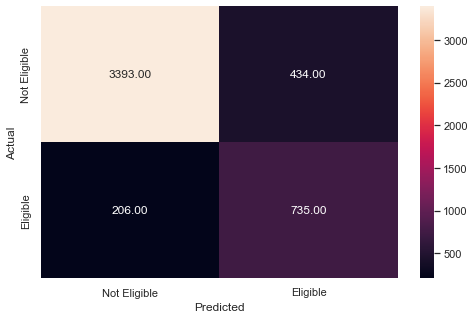

In [105]:
# Checking performance on the training data based on the tuned model

y_pred_train2 = d_tree_tuned.predict(X_train)

metrics_score(y_train, y_pred_train2)

#### Checking the performance on the test dataset

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       944
           1       0.65      0.73      0.69       248

    accuracy                           0.86      1192
   macro avg       0.79      0.81      0.80      1192
weighted avg       0.87      0.86      0.87      1192



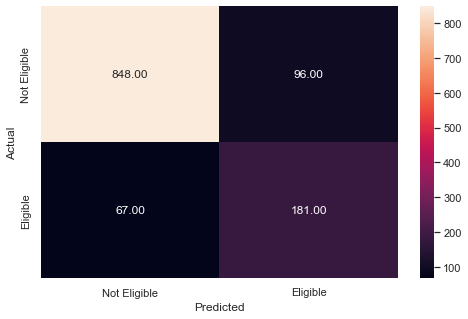

In [106]:
# Checking performance on the testing data based on the tuned model

y_pred_test2 = d_tree_tuned.predict(X_test)

metrics_score(y_test, y_pred_test2)


**Insights**
- The recall on the test data has significantly improved from the default tree.

#### Plotting the Decision Tree

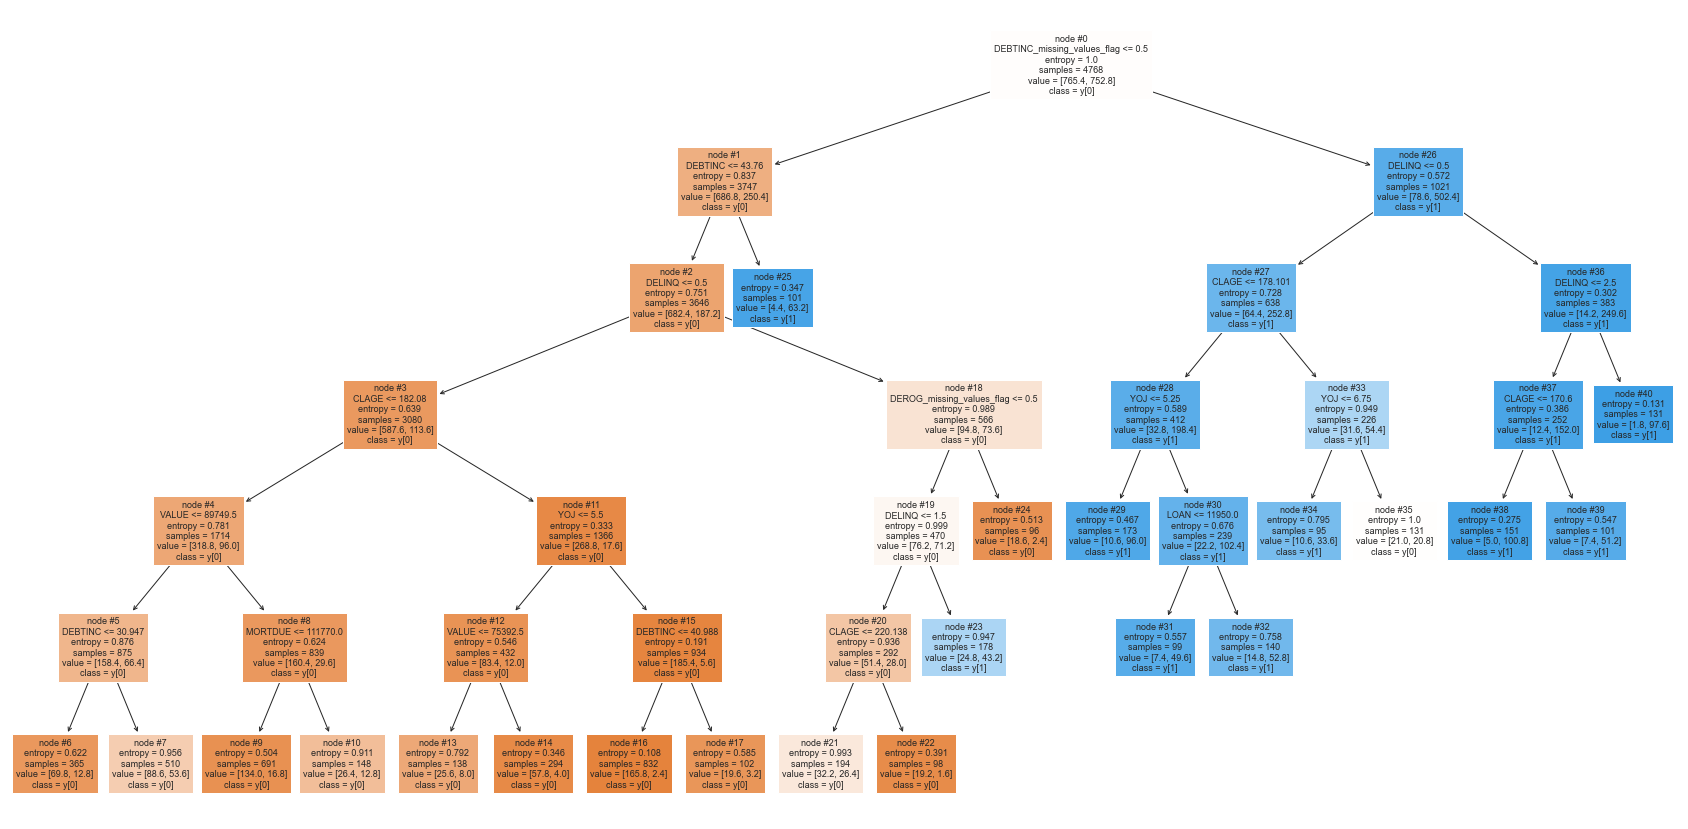

In [107]:
# Plot the decision  tree and analyze it to build the decision rule

features = list(X.columns)

plt.figure(figsize = (30, 15))

tree.plot_tree(d_tree_tuned, feature_names = features, filled = True, fontsize = 9, node_ids = True, class_names = True)

plt.show()

In [108]:
print (pd.DataFrame(d_tree_tuned.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                  Imp
DEBTINC_missing_values_flag  0.580673
DEBTINC                      0.177136
DELINQ                       0.104624
CLAGE                        0.075864
YOJ                          0.019838
VALUE                        0.017984
DEROG_missing_values_flag    0.012196
MORTDUE                      0.009898
LOAN                         0.001787
REASON_HomeImp               0.000000
CLNO_missing_values_flag     0.000000
JOB_Other                    0.000000
JOB_Office                   0.000000
CLAGE_missing_values_flag    0.000000
JOB_ProfExe                  0.000000
JOB_Sales                    0.000000
NINQ_missing_values_flag     0.000000
JOB_missing_values_flag      0.000000
DELINQ_missing_values_flag   0.000000
YOJ_missing_values_flag      0.000000
REASON_missing_values_flag   0.000000
VALUE_missing_values_flag    0.000000
MORTDUE_missing_values_flag  0.000000
CLNO                         0.000000
NINQ                         0.000000
DEROG       

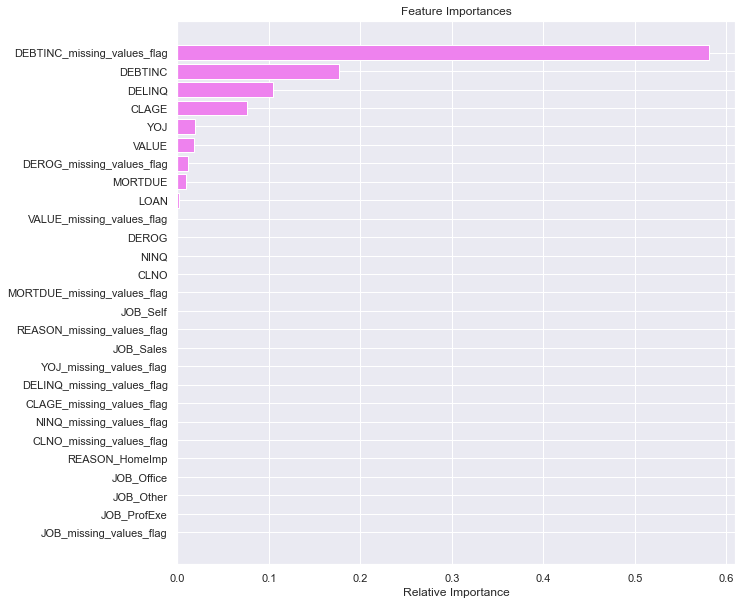

In [109]:
# Plotting the feature importance
importances = d_tree_tuned.feature_importances_

indices = np.argsort(importances)

plt.figure(figsize = (10, 10))

plt.title('Feature Importances')

plt.barh(range(len(indices)), importances[indices], color = 'violet', align = 'center')

plt.yticks(range(len(indices)), [features[i] for i in indices])

plt.xlabel('Relative Importance')

plt.show()

#### Deduce the business rules apparent from the Decision Tree and write them down: 
- If Debt to Income is omitted from the application, the borrow is almost garunteed to default on their loan
- If Debt to Income is included and it is less than 43:
    - The Borrow is likely to repay the loan if they have less than 1.5 delinquent credit lines
    - The Borrow is likely to Default if they have more than 1.5 delinquent credit lines.
- If debt to income is included and it is more than 43:
    - The bowwower is likely to repay their loan if their credit age is greater than 288 months (24 years)
    - The borrower is likely to default on their loan if their credit age is less than 288 months (24 years)

### **Building a Random Forest Classifier**

**Random Forest is a bagging algorithm where the base models are Decision Trees.** Samples are taken from the training data and on each sample a decision tree makes a prediction. 

**The results from all the decision trees are combined together and the final prediction is made using voting or averaging.**

In [110]:
# Defining Random forest CLassifier
rf_estimator = RandomForestClassifier(criterion = "entropy", random_state=7)

rf_estimator.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', random_state=7)

#### Checking the performance on the train dataset

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3827
           1       1.00      1.00      1.00       941

    accuracy                           1.00      4768
   macro avg       1.00      1.00      1.00      4768
weighted avg       1.00      1.00      1.00      4768



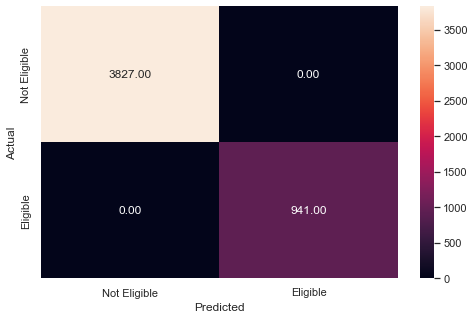

In [111]:
#Checking performance on the training data
y_pred_train3 = rf_estimator.predict(X_train)

metrics_score(y_train, y_pred_train3)

#### Checking the performance on the test dataset

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       944
           1       0.85      0.69      0.76       248

    accuracy                           0.91      1192
   macro avg       0.88      0.83      0.85      1192
weighted avg       0.91      0.91      0.90      1192



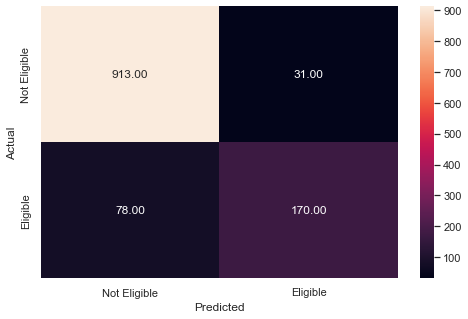

In [112]:
# Checking performance on the test data

y_pred_test3 = rf_estimator.predict(X_test)

metrics_score(y_test, y_pred_test3)

**Observations:**
- The recall and accuracy on this model look ok but the data in the matrix is showing only 16% of the applications are getting approved and 58% of the rejected applications would have been repaid if issued. This seems like more of a loss to the company than 20% of them defaulting

### **Build a Random Forest model with Class Weights**

In [113]:
# Defining Random Forest model with class weights class_weight={0: 0.2, 1: 0.8}

rf_estimator_weighted = RandomForestClassifier(criterion = "entropy", random_state=7, class_weight={0: 0.2, 1: 0.8})

# Fitting Random Forest model

rf_estimator_weighted.fit(X_train,y_train)


RandomForestClassifier(class_weight={0: 0.2, 1: 0.8}, criterion='entropy',
                       random_state=7)

#### Checking the performance on the train dataset

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3827
           1       1.00      1.00      1.00       941

    accuracy                           1.00      4768
   macro avg       1.00      1.00      1.00      4768
weighted avg       1.00      1.00      1.00      4768



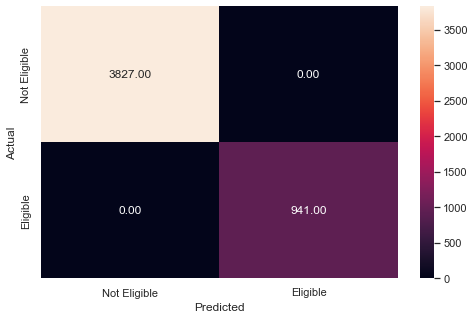

In [114]:
# Checking performance on the train data


y_pred_train_wt = rf_estimator_weighted.predict(X_train)

metrics_score(y_train, y_pred_train_wt)

#### Checking the performance on the test dataset

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       944
           1       0.87      0.67      0.76       248

    accuracy                           0.91      1192
   macro avg       0.89      0.82      0.85      1192
weighted avg       0.91      0.91      0.91      1192



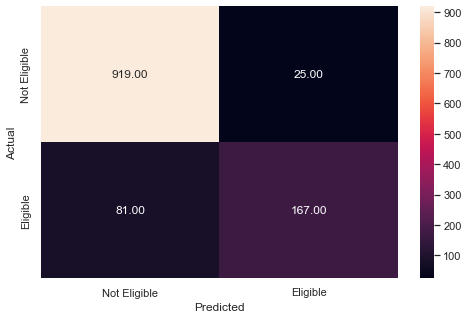

In [115]:
# Checking performance on the test data

y_pred_test_wt = rf_estimator_weighted.predict(X_test)

metrics_score(y_test, y_pred_test_wt)

### **Think about it:**
- Can we try different weights?
    - Yes
- If yes, should we increase or decrease class weights for different classes? 
    - We should apply the weights to correct reflect yhe imbalance in the data set

### **Tuning the Random Forest**

* Hyperparameter tuning is tricky in the sense that **there is no direct way to calculate how a change in the hyperparameter value will reduce the loss of your model**, so we usually resort to experimentation. We'll use Grid search to perform hyperparameter tuning.
* **Grid search is a tuning technique that attempts to compute the optimum values of hyperparameters.** 
* **It is an exhaustive search** that is performed on the specific parameter values of a model.
* The parameters of the estimator/model used to apply these methods are **optimized by cross-validated grid-search** over a parameter grid.


**n_estimators**: The number of trees in the forest.

**min_samples_split**: The minimum number of samples required to split an internal node:

**min_samples_leaf**: The minimum number of samples required to be at a leaf node. 

**max_features{“auto”, “sqrt”, “log2”, 'None'}**: The number of features to consider when looking for the best split.

- If “auto”, then max_features=sqrt(n_features).

- If “sqrt”, then max_features=sqrt(n_features) (same as “auto”).

- If “log2”, then max_features=log2(n_features).

- If None, then max_features=n_features.

You can learn more about Random Forest Hyperparameters from the link given below and try to tune them

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

#### **Warning:** This may take a long time depending on the parameters you tune. 

In [116]:
# Choose the type of classifier. 

rf_estimator_tuned = RandomForestClassifier(criterion = "entropy", random_state = 7)


# Grid of parameters to choose from
parameters = {"n_estimators": [110, 120],
    "max_depth": [6, 7],
    "min_samples_leaf": [20, 25],
    "max_features": [0.8, 0.9],
    "max_samples": [0.9, 1],
    "class_weight": ["balanced",{0: 0.2, 1: 0.8}]
             }


# Type of scoring used to compare parameter combinations

scorer = metrics.make_scorer(recall_score, pos_label = 1)


# Run the grid search

grid_obj = GridSearchCV(rf_estimator_tuned, parameters, scoring = scorer, cv = 5)


#fit the GridSearch on train dataset

grid_obj = grid_obj.fit(X_train, y_train)


# Set the clf to the best combination of parameters

rf_estimator_tuned = grid_obj.best_estimator_


# Fit the best algorithm to the data. 

rf_estimator_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=7, max_features=0.8, max_samples=0.9,
                       min_samples_leaf=20, n_estimators=120, random_state=7)

#### Checking the performance on the train dataset

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      3827
           1       0.69      0.81      0.74       941

    accuracy                           0.89      4768
   macro avg       0.82      0.86      0.84      4768
weighted avg       0.90      0.89      0.89      4768



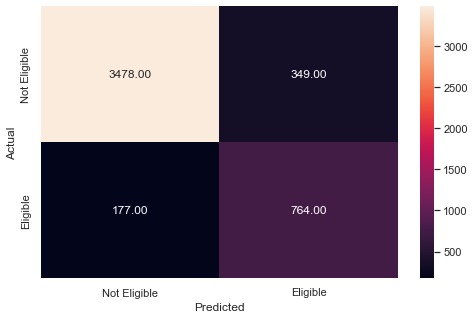

In [117]:
# Checking performance on the training data

y_pred_train_tuned = rf_estimator_tuned.predict(X_train)

metrics_score(y_train, y_pred_train_tuned)

#### Checking the performance on the test dataset

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       944
           1       0.69      0.73      0.71       248

    accuracy                           0.87      1192
   macro avg       0.81      0.82      0.81      1192
weighted avg       0.88      0.87      0.88      1192



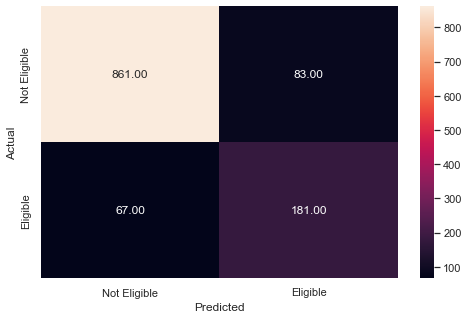

In [118]:
# Checking performace on test dataset


y_pred_test_tuned = rf_estimator_tuned.predict(X_test)

metrics_score(y_test, y_pred_test_tuned)

**Insights:**
- Accuracy has decreased from the default Random Forest, but is still better than the Tuned Decision Tree.
- Recall has improved from the default Random Forest models but isstill not as good as the tuned decision tree.

#### Plot the Feature importance of the tuned Random Forest

Text(0.5, 0, 'Relative Importance')

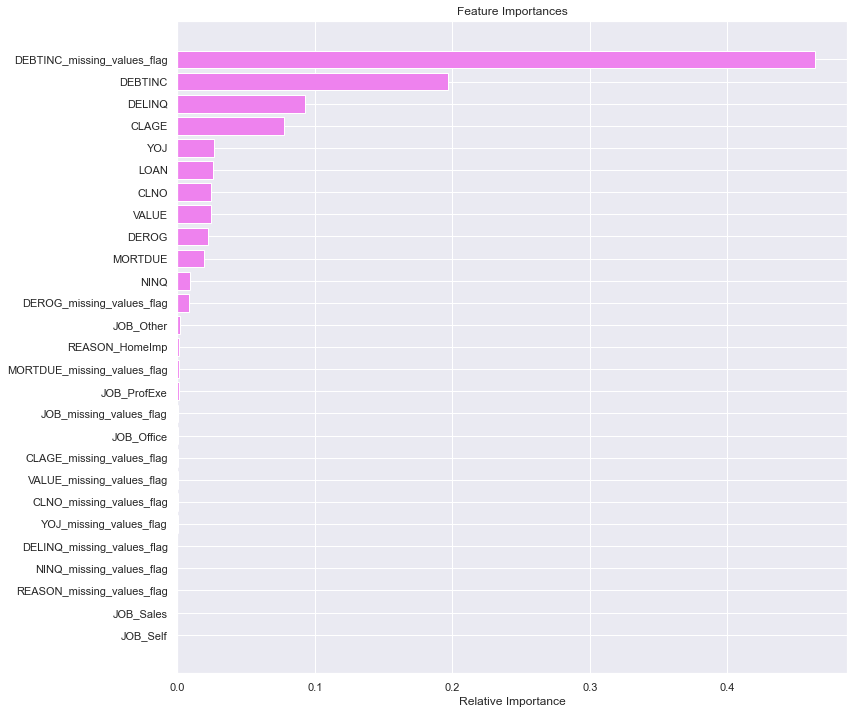

In [119]:
# importance of features in the tree building ( The importance of a feature is computed as the 
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )
# Checking performace on test dataset


importances = rf_estimator_tuned.feature_importances_

indices = np.argsort(importances)

feature_names = X.columns

feature_mask = rf_estimator_tuned.feature_importances_>0.005

plt.figure(figsize = (12, 12))

plt.title('Feature Importances')

plt.barh(range(len(indices)), importances[indices], color = 'violet', align = 'center')

plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel('Relative Importance')

#plt.show()

### **Think about it:**
- We have only built 3 models so far, Logistic Regression, Decision Tree and Random Forest 
- We can build other Machine Learning classification models like kNN, LDA, QDA or even Support Vector Machines (SVM).
- Can we also perform feature engineering and create model features and build a more robust and accurate model for this problem statement? 
    Of course we can! But that kind of experimentation would take longer the time given to us for this project.

### **Comparing Model Performances**

In [120]:
def get_recall_score(model,flag=True,X_train=X_train,X_test=X_test):
    '''
    model : classifier to predict values of X

    '''
    a = [] # defining an empty list to store train and test results
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)
    a.append(train_recall) # adding train recall to list 
    a.append(test_recall) # adding test recall to list
    
    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True: 
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test))
    
    return a # returning the list with train and test scores

In [121]:
##  Function to calculate precision score
def get_precision_score(model,flag=True,X_train=X_train,X_test=X_test):
    '''
    model : classifier to predict values of X

    '''
    b = []  # defining an empty list to store train and test results
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)
    b.append(train_precision) # adding train precision to list
    b.append(test_precision) # adding test precision to list
    
    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True: 
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test))

    return b # returning the list with train and test scores

In [122]:
##  Function to calculate accuracy score
def get_accuracy_score(model,flag=True,X_train=X_train,X_test=X_test):
    '''
    model : classifier to predict values of X

    '''
    c = [] # defining an empty list to store train and test results
    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)
    c.append(train_acc) # adding train accuracy to list
    c.append(test_acc) # adding test accuracy to list
    
    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Accuracy on training set : ",model.score(X_train,y_train))
        print("Accuracy on test set : ",model.score(X_test,y_test))
    
    return c # returning the list with train and test scores

In [123]:
# Make the list of all the model names 

models = [lr,
          d_tree, 
          d_tree_tuned, 
          rf_estimator, 
          rf_estimator_weighted,
          rf_estimator_tuned]


# defining empty lists to add train and test results
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []

# looping through all the models to get the accuracy,recall and precision scores
for model in models:
     # accuracy score
    j = get_accuracy_score(model,False)
    acc_train.append(j[0])
    acc_test.append(j[1])

    # recall score
    k = get_recall_score(model,False)
    recall_train.append(k[0])
    recall_test.append(k[1])

    # precision score
    l = get_precision_score(model,False)
    precision_train.append(l[0])
    precision_test.append(l[1])

In [124]:
# Mention the Model names in the list. for example 'Model': ['Decision Tree', 'Tuned Decision Tree'..... write tht names of all model built]


comparison_frame = pd.DataFrame({'Model':[ 'Logistic Regression', 'Decision Tree', 'Decision Tree Tuned', 'Random Forest', 'Random Forest Weighted', 'Random Forest Tuned'], 
                                          'Train_Accuracy': acc_train,
                                          'Test_Accuracy': acc_test,
                                          'Train_Recall': recall_train,
                                          'Test_Recall': recall_test,
                                          'Train_Precision': precision_train,
                                          'Test_Precision': precision_test}) 
comparison_frame

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision
0,Logistic Regression,0.802643,0.791946,0.000000,0.000000,0.000000,0.000000
1,Decision Tree,1.000000,0.869128,1.000000,0.629032,1.000000,0.709091
2,Decision Tree Tuned,0.865772,0.863255,0.781084,0.729839,0.628743,0.653430
3,Random Forest,1.000000,0.908557,1.000000,0.685484,1.000000,0.845771
4,Random Forest Weighted,1.000000,0.911074,1.000000,0.673387,1.000000,0.869792
5,Random Forest Tuned,0.889681,0.874161,0.811902,0.729839,0.686433,0.685606


**Insights:**
- Logistic Regression is the worst preforming model of the 6
- Random Forest in general gave the best results
- Decision Tree gave the most interpretible results
- Both Random Forest and Decision Tree had the 4 variables, in the same order, for their feature importances, thus we can leverage the interpretability of the decision tree while leaning on the confirmation of the random forest and its higher accuracacy in making reccomendations to our client.

**1. Refined insights -** What are the most meaningful insights from the data relevant to the problem?
- The client needs to enforce requirement of the Debt to Income Ratios in loan applications
- The client should be wary of applicants with high delinquent credit lines, especially in applicants with a younger credit history.

**2. Comparison of various techniques and their relative performance -** How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?
- Random Forest was consitently a better preforming model than the others.
- I feel improvements to the model is going to largely come from improvements to the data. Alot of the applicant information was missing data and had to be treated. We could apply different treament techniques such as: 
    - creating additional "unknown" categories within the categorical columns
    - selectively treating the outliers based on the distribution of their data points
    - Filling in missing numerical values based on the average ratio comparison to other data points as compared to the other applicant information.
- We could also experiement with different tuning methods, but i do not think there would be a significant difference, especially with the use of gridsearch. 

**3. Proposal for the final solution design -** What model do you propose to be adopted? Why is this the best solution to adopt?
- I am proposing that the Tuned Decision Tree be adopted as it is the most interpretable and has the same ording of important features as the more accurate Random Forest Model.